# Phase 10-pre.B: Volatility Forecasting Feasibility Check

**Date:** 2026-03-28 | **Author:** Dmytro Khvedchuk | **Branch:** `research/I-93-ensemble-da-gating-test`

---

## Pre-Registration Declaration

This test runs **alongside** the DA gating test (Phase 10-pre.A) to determine whether
ML models can forecast forward realized volatility better than econometric baselines.

**Decision rule (pre-registered):**
- If **MZ R² > 0** AND **QLIKE(ML) < QLIKE(GARCH)**: volatility forecasting is **VIABLE**
  → Phase 10 uses vol forecasting as the primary regression target
- Otherwise: fall back to return magnitude regression

**Asset / Bar:** BTCUSDT / dollar bars (~5100+ bars after stationarity transforms)

**Models tested:**
1. **GARCH(1,1)** with Student-t innovations — econometric baseline
2. **HAR-RV** (Heterogeneous Autoregressive RV) — standard econometric vol model
3. **Ridge Regression** (alpha=1.0, StandardScaler) — linear ML baseline
4. **LightGBM Regressor** — nonlinear ML model (conservative hyperparameters)

**Targets:**
- `fwd_vol_4` — forward realized volatility, 4-bar horizon: std(r_{t+1}, ..., r_{t+4})
- `fwd_vol_24` — forward realized volatility, 24-bar horizon: std(r_{t+1}, ..., r_{t+24})

**Validation:** CPCV C(6,2) = 15 folds, purge=1 bar, embargo=5 bars

**Key metrics:**
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| QLIKE | mean(σ²_true/σ²_pred - log(σ²_true/σ²_pred) - 1) | Quasi-likelihood loss; lower is better; penalizes vol underestimation |
| MZ R² | R² from regressing σ²_actual on σ²_predicted | Forecast informativeness; >0 means forecasts explain variance |
| MZ β | Slope of Mincer-Zarnowitz regression | Calibration; β≈1 means unbiased |
| MAE(log-vol) | mean(|log(σ_true) - log(σ_pred)|) | Scale-free error on log volatility |

**RC2 Context (GARCH findings):**
- All 4 assets show near-IGARCH behavior (α+β ≈ 1.000)
- Student-t innovation preferred over Normal
- BDS test rejects i.i.d. for GARCH residuals → ML may capture residual structure
- Sign bias detected → leverage effects exist that GARCH(1,1) misses

In [1]:
# === Section 1: Setup & Imports ===
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

_PROJECT_ROOT: Path = Path.cwd().parent if Path.cwd().name == "research" else Path.cwd()
os.chdir(_PROJECT_ROOT)
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*arch_model.*")

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from arch import arch_model
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler

# Project imports
from src.app.system.database.connection import ConnectionManager
from src.app.research.application.data_loader import DataLoader
from src.app.features.application.feature_matrix import FeatureMatrixBuilder
from src.app.features.domain.value_objects import FeatureConfig
from src.app.research.application.cpcv_splitter import CPCVConfig, CPCVSplitter

# Plot settings
%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (14, 8),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)
COLORS: dict[str, str] = {
    "garch": "#95a5a6",
    "har": "#f39c12",
    "ridge": "#3498db",
    "lgbm": "#e74c3c",
    "perfect": "#2ecc71",
}
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.6f}".format)

# Figure output directory
FIG_DIR: Path = Path("research/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Database connection reference
db_connection: ConnectionManager | None = None

print(f"Project root: {_PROJECT_ROOT}")
print("Setup complete.")

Project root: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis
Setup complete.


In [2]:
# === Section 1.2: Load Data & Build Feature Matrix ===
db_connection = ConnectionManager()
db_connection.initialize()
loader: DataLoader = DataLoader(db_connection)

# Discover dollar bar config hash for BTCUSDT
bar_configs: list[tuple[str, str]] = loader.get_available_bar_configs("BTCUSDT")
dollar_configs: list[tuple[str, str]] = [(bt, ch) for bt, ch in bar_configs if bt == "dollar"]
assert len(dollar_configs) > 0, "No dollar bar configs found for BTCUSDT"
DOLLAR_CONFIG_HASH: str = dollar_configs[0][1]
print(f"Using dollar bar config_hash: {DOLLAR_CONFIG_HASH}")

# Load bars as Pandas
bars_pd: pd.DataFrame = loader.load_bars("BTCUSDT", "dollar", DOLLAR_CONFIG_HASH)
print(f"Loaded {len(bars_pd)} BTCUSDT dollar bars")
print(f"Date range: {bars_pd['start_ts'].min()} to {bars_pd['start_ts'].max()}")

# Convert to Polars for FeatureMatrixBuilder
bars_pl: pl.DataFrame = pl.from_pandas(bars_pd).rename({"start_ts": "timestamp"})

# Build feature matrix with 21 features + targets
builder: FeatureMatrixBuilder = FeatureMatrixBuilder()
config: FeatureConfig = FeatureConfig(compute_targets=True, drop_na=True)
feature_set = builder.build(bars_pl, config)

print(f"\nFeature matrix: {feature_set.n_rows_clean} rows (from {feature_set.n_rows_raw} raw)")
print(f"Features ({len(feature_set.feature_columns)}): {feature_set.feature_columns}")
print(f"Targets: {feature_set.target_columns}")

2026-03-28 22:18:50.863 | INFO     | src.app.system.database.connection:initialize:77 - Creating DuckDB engine (path=/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/data/market.duckdb)
2026-03-28 22:18:50.960 | INFO     | src.app.system.database.connection:initialize:86 - DuckDB connection verified successfully


Using dollar bar config_hash: 76c279d83686171b
Loaded 5287 BTCUSDT dollar bars
Date range: 2020-01-01 00:00:00+00:00 to 2026-03-12 15:00:00+00:00

Feature matrix: 5164 rows (from 5287 raw)
Features (23): ('amihud_24', 'atr_14', 'bbpctb_20_2.0', 'bbwidth_20_2.0', 'ema_xover_8_21', 'gk_vol_24', 'hurst_100', 'logret_1', 'logret_12', 'logret_24', 'logret_4', 'obv_slope_14', 'park_vol_24', 'ret_zscore_24', 'roc_1', 'roc_12', 'roc_4', 'rsi_14', 'rv_12', 'rv_24', 'rv_48', 'slope_14', 'vol_zscore_24')
Targets: ('fwd_logret_1', 'fwd_logret_24', 'fwd_logret_4', 'fwd_vol_24', 'fwd_vol_4')


## Section 2: Target Preparation

Two volatility targets from the feature matrix:
- **`fwd_vol_4`**: std(r_{t+1}, ..., r_{t+4}) — short-horizon (1-2 days for dollar bars)
- **`fwd_vol_24`**: std(r_{t+1}, ..., r_{t+24}) — medium-horizon (8-12 days)

We apply the same stationarity transforms to features as the gating test, then prepare
the volatility targets. Since volatility is always positive, we also prepare **log-volatility**
targets for models that benefit from approximately normal targets.

In [3]:
# === Section 2.1: Prepare Features & Volatility Targets ===

# Convert feature matrix to Pandas
df: pd.DataFrame = feature_set.df.to_pandas()

# Drop atr_14 and rsi_14 if still present (Phase 7.2 — constant features excluded)
DROP_FEATURES: set[str] = {"atr_14", "rsi_14"}
feature_cols: list[str] = [c for c in feature_set.feature_columns if c not in DROP_FEATURES]
print(f"Features after exclusion: {len(feature_cols)}")

# --- Apply 7 stationarity transformations (Phase 7.3 policy ST1-ST4) ---
# Rolling z-score: (x - rolling_mean(24)) / rolling_std(24)
ROLLING_ZSCORE_FEATURES: list[str] = ["amihud_24", "gk_vol_24"]
# First difference: x.diff()
FIRST_DIFF_FEATURES: list[str] = ["bbwidth_20_2.0", "park_vol_24", "rv_12", "rv_24", "rv_48"]

for col in ROLLING_ZSCORE_FEATURES:
    if col in df.columns:
        rolling_mean: pd.Series = df[col].rolling(24, min_periods=24).mean()
        rolling_std: pd.Series = df[col].rolling(24, min_periods=24).std()
        df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-12)
        print(f"  Transformed {col}: rolling z-score (window=24)")

for col in FIRST_DIFF_FEATURES:
    if col in df.columns:
        df[col] = df[col].diff()
        print(f"  Transformed {col}: first difference")

# --- Volatility targets ---
VOL_TARGETS: list[str] = ["fwd_vol_4", "fwd_vol_24"]
for col in VOL_TARGETS:
    assert col in df.columns, f"Missing target column: {col}"
    print(f"\n{col} summary (pre-clean):")
    print(f"  non-null: {df[col].notna().sum()}, null: {df[col].isna().sum()}")
    print(f"  min={df[col].min():.8f}, max={df[col].max():.8f}, mean={df[col].mean():.8f}")

# --- Drop NaN rows from stationarity transforms + vol targets ---
n_before_drop: int = len(df)
df = df.dropna(subset=feature_cols + VOL_TARGETS).reset_index(drop=True)
n_after_drop: int = len(df)
print(f"\nDropped {n_before_drop - n_after_drop} rows from stationarity transforms + target NaN")

# --- Replace any zero or negative vol values with a tiny epsilon ---
# (forward_volatility can be exactly 0 if all returns in the window are identical)
EPS_VOL: float = 1e-12
for col in VOL_TARGETS:
    n_zero: int = (df[col] <= 0).sum()
    if n_zero > 0:
        print(f"  WARNING: {n_zero} zero/negative values in {col}, replacing with eps={EPS_VOL}")
        df.loc[df[col] <= 0, col] = EPS_VOL

# --- Final X and y arrays ---
X: np.ndarray = df[feature_cols].values.astype(np.float64)
y_vol4: np.ndarray = df["fwd_vol_4"].values.astype(np.float64)
y_vol24: np.ndarray = df["fwd_vol_24"].values.astype(np.float64)

# Also need 1-bar log returns for GARCH model
# Extract the logret_1 column (backward-looking, already computed)
returns_series: pd.Series = df["logret_1"].copy()

# --- Sanity checks ---
assert not np.any(np.isnan(X)), "NaN found in feature matrix!"
assert not np.any(np.isinf(X)), "Inf found in feature matrix!"
assert np.all(y_vol4 > 0), "Non-positive values in fwd_vol_4!"
assert np.all(y_vol24 > 0), "Non-positive values in fwd_vol_24!"

N_FINAL: int = len(df)

print(f"\n{'=' * 60}")
print("VOL FEASIBILITY DATA SUMMARY")
print(f"{'=' * 60}")
print(f"N_final:            {N_FINAL:,}")
print(f"N_features:         {len(feature_cols)}")
print(f"fwd_vol_4  range:   [{y_vol4.min():.8f}, {y_vol4.max():.8f}]")
print(f"fwd_vol_4  mean:    {y_vol4.mean():.8f}")
print(f"fwd_vol_24 range:   [{y_vol24.min():.8f}, {y_vol24.max():.8f}]")
print(f"fwd_vol_24 mean:    {y_vol24.mean():.8f}")
print(f"Feature list:       {feature_cols}")

Features after exclusion: 21
  Transformed amihud_24: rolling z-score (window=24)
  Transformed gk_vol_24: rolling z-score (window=24)
  Transformed bbwidth_20_2.0: first difference
  Transformed park_vol_24: first difference
  Transformed rv_12: first difference
  Transformed rv_24: first difference
  Transformed rv_48: first difference

fwd_vol_4 summary (pre-clean):
  non-null: 5164, null: 0
  min=0.00027430, max=0.07160376, mean=0.01627250

fwd_vol_24 summary (pre-clean):
  non-null: 5164, null: 0
  min=0.00325993, max=0.04996215, mean=0.01773816

Dropped 23 rows from stationarity transforms + target NaN

VOL FEASIBILITY DATA SUMMARY
N_final:            5,141
N_features:         21
fwd_vol_4  range:   [0.00027430, 0.07160376]
fwd_vol_4  mean:    0.01623841
fwd_vol_24 range:   [0.00325993, 0.04996215]
fwd_vol_24 mean:    0.01767961
Feature list:       ['amihud_24', 'bbpctb_20_2.0', 'bbwidth_20_2.0', 'ema_xover_8_21', 'gk_vol_24', 'hurst_100', 'logret_1', 'logret_12', 'logret_24', 'l

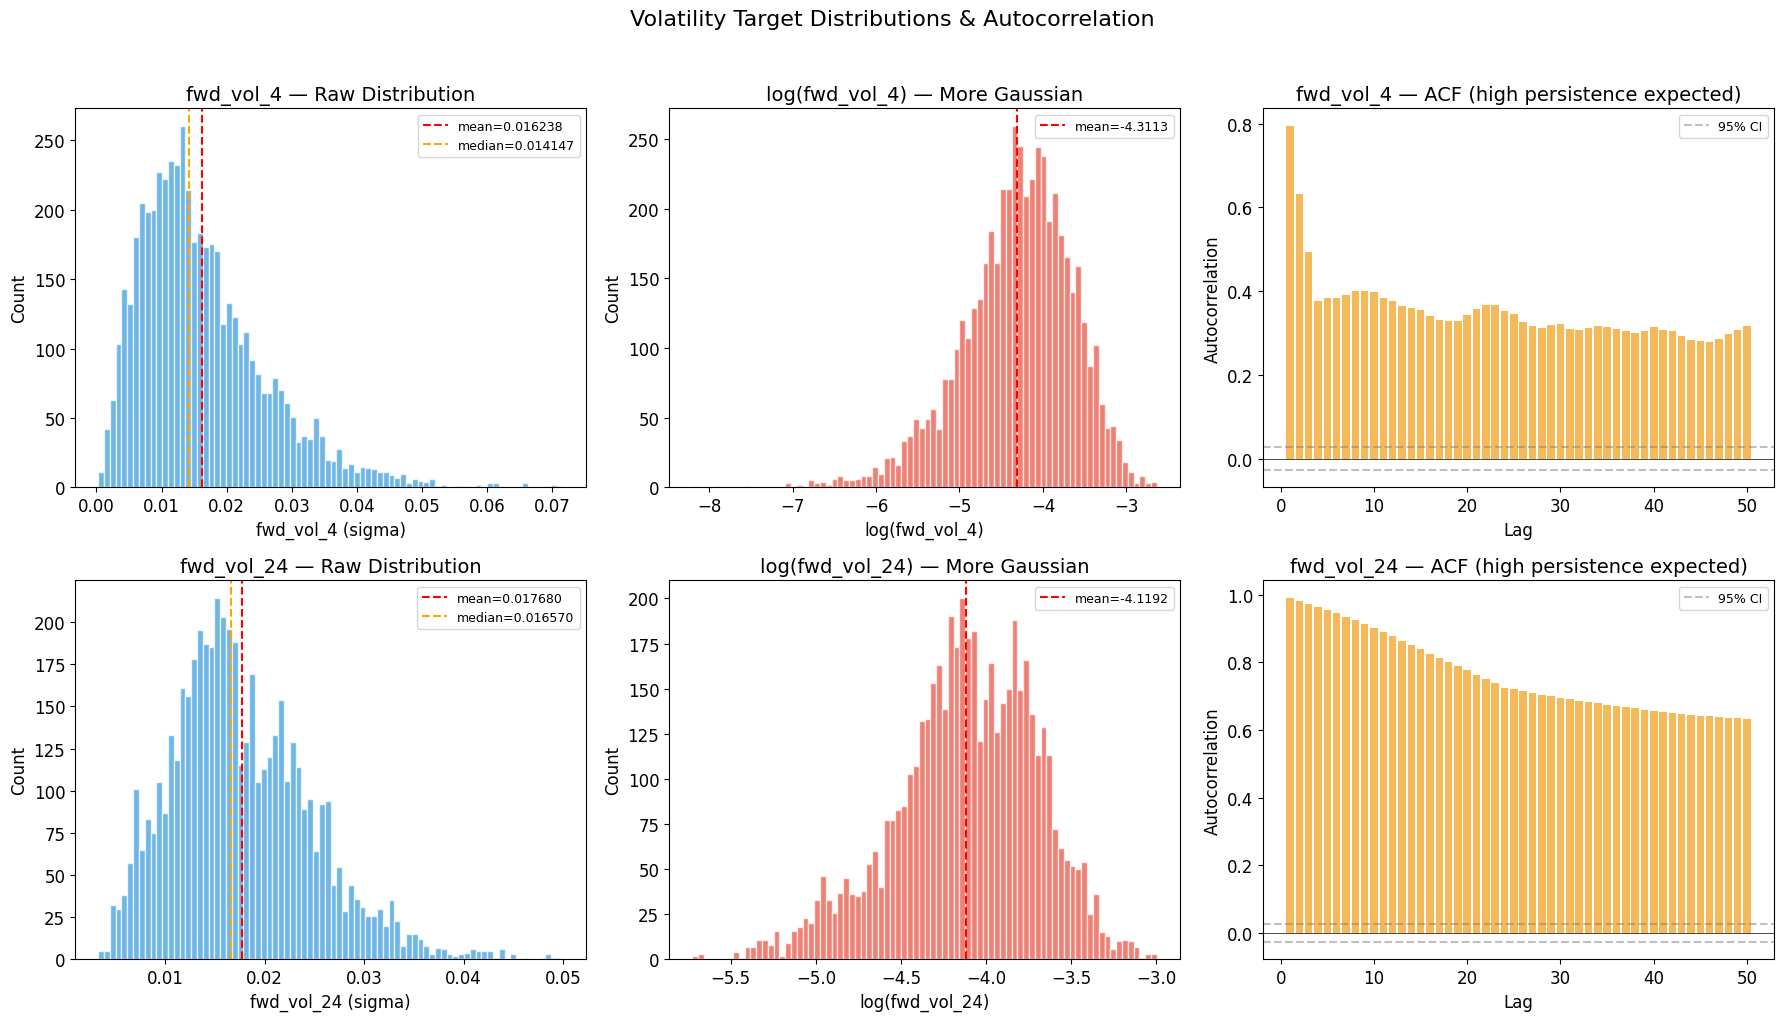

fwd_vol_4:
  Raw  — skew=1.230, kurt=2.199
  Log  — skew=-0.684, kurt=1.055
  ACF(1)=0.7952, ACF(5)=0.3839, ACF(24)=0.3520
fwd_vol_24:
  Raw  — skew=0.733, kurt=0.761
  Log  — skew=-0.456, kurt=0.202
  ACF(1)=0.9910, ACF(5)=0.9550, ACF(24)=0.7251


In [4]:
# === Section 2.2: Target Distribution Analysis ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (target_name, y_target) in enumerate([("fwd_vol_4", y_vol4), ("fwd_vol_24", y_vol24)]):
    # (a) Raw distribution
    ax: plt.Axes = axes[row, 0]
    ax.hist(y_target, bins=80, color=COLORS["ridge"], alpha=0.7, edgecolor="white")
    ax.axvline(np.mean(y_target), color="red", linestyle="--", label=f"mean={np.mean(y_target):.6f}")
    ax.axvline(np.median(y_target), color="orange", linestyle="--", label=f"median={np.median(y_target):.6f}")
    ax.set_xlabel(f"{target_name} (sigma)")
    ax.set_ylabel("Count")
    ax.set_title(f"{target_name} — Raw Distribution")
    ax.legend(fontsize=9)

    # (b) Log distribution
    ax = axes[row, 1]
    log_target: np.ndarray = np.log(y_target)
    ax.hist(log_target, bins=80, color=COLORS["lgbm"], alpha=0.7, edgecolor="white")
    ax.axvline(np.mean(log_target), color="red", linestyle="--", label=f"mean={np.mean(log_target):.4f}")
    ax.set_xlabel(f"log({target_name})")
    ax.set_ylabel("Count")
    ax.set_title(f"log({target_name}) — More Gaussian")
    ax.legend(fontsize=9)

    # (c) Autocorrelation of vol target
    ax = axes[row, 2]
    max_lag: int = 50
    acf_values: list[float] = []
    for lag in range(1, max_lag + 1):
        corr: float = np.corrcoef(y_target[:-lag], y_target[lag:])[0, 1]
        acf_values.append(corr)
    ax.bar(range(1, max_lag + 1), acf_values, color=COLORS["har"], alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(1.96 / np.sqrt(len(y_target)), color="gray", linestyle="--", alpha=0.5, label="95% CI")
    ax.axhline(-1.96 / np.sqrt(len(y_target)), color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(f"{target_name} — ACF (high persistence expected)")
    ax.legend(fontsize=9)

plt.suptitle("Volatility Target Distributions & Autocorrelation", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig01_target_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness and kurtosis
from scipy.stats import skew, kurtosis

for name, y_t in [("fwd_vol_4", y_vol4), ("fwd_vol_24", y_vol24)]:
    log_y: np.ndarray = np.log(y_t)
    print(f"{name}:")
    print(f"  Raw  — skew={skew(y_t):.3f}, kurt={kurtosis(y_t):.3f}")
    print(f"  Log  — skew={skew(log_y):.3f}, kurt={kurtosis(log_y):.3f}")
    print(
        f"  ACF(1)={np.corrcoef(y_t[:-1], y_t[1:])[0, 1]:.4f}, "
        f"ACF(5)={np.corrcoef(y_t[:-5], y_t[5:])[0, 1]:.4f}, "
        f"ACF(24)={np.corrcoef(y_t[:-24], y_t[24:])[0, 1]:.4f}"
    )

## Section 3: Evaluation Metrics

Define the three key metrics for volatility forecast evaluation:

1. **QLIKE Loss** — quasi-likelihood, the standard loss function for volatility forecasting
2. **Mincer-Zarnowitz Regression** — forecast informativeness and calibration
3. **MAE on log-vol** — scale-free error measure

All metrics operate on **variance** (sigma-squared) for QLIKE and MZ, and on **sigma** for MAE(log-vol).

In [5]:
# === Section 3.1: Metric Functions ===


def qlike_loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """QLIKE loss (quasi-likelihood) for volatility forecast evaluation.

    Operates on VARIANCE (sigma-squared), not sigma.
    QLIKE = mean(sigma2_true / sigma2_pred - log(sigma2_true / sigma2_pred) - 1)

    Lower is better. Heavily penalizes underestimation of volatility,
    which is the dangerous direction for risk management.

    Args:
        y_true: Realized variance (sigma^2). Must be > 0.
        y_pred: Predicted variance (sigma^2). Must be > 0.

    Returns:
        QLIKE loss value.
    """
    # Convert sigma to variance
    var_true: np.ndarray = y_true**2
    var_pred: np.ndarray = np.maximum(y_pred**2, 1e-20)  # floor to avoid div-by-zero
    ratio: np.ndarray = var_true / var_pred
    return float(np.mean(ratio - np.log(ratio) - 1))


def mincer_zarnowitz(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Mincer-Zarnowitz regression for forecast evaluation.

    Regresses actual variance on predicted variance:
        sigma2_actual = alpha + beta * sigma2_predicted + epsilon

    A well-calibrated forecast has alpha=0, beta=1.
    R-squared measures forecast informativeness.

    Args:
        y_true: Realized volatility (sigma). Must be > 0.
        y_pred: Predicted volatility (sigma). Must be > 0.

    Returns:
        Dictionary with mz_r2, mz_alpha, mz_beta.
    """
    var_true: np.ndarray = y_true**2
    var_pred: np.ndarray = y_pred**2
    reg: LinearRegression = LinearRegression()
    reg.fit(var_pred.reshape(-1, 1), var_true)
    r2: float = float(reg.score(var_pred.reshape(-1, 1), var_true))
    return {
        "mz_r2": r2,
        "mz_alpha": float(reg.intercept_),
        "mz_beta": float(reg.coef_[0]),
    }


def mae_log_vol(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """MAE on log-volatility.

    A scale-free error measure: mean(|log(sigma_true) - log(sigma_pred)|).
    Works in log-space so percentage errors in small and large vol are weighted equally.

    Args:
        y_true: Realized volatility (sigma). Must be > 0.
        y_pred: Predicted volatility (sigma). Must be > 0.

    Returns:
        MAE on log-volatility.
    """
    return float(np.mean(np.abs(np.log(y_true) - np.log(np.maximum(y_pred, 1e-20)))))


def compute_all_vol_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Compute all three volatility forecast metrics.

    Args:
        y_true: Realized volatility (sigma).
        y_pred: Predicted volatility (sigma).

    Returns:
        Dictionary with qlike, mz_r2, mz_alpha, mz_beta, mae_logvol.
    """
    mz: dict[str, float] = mincer_zarnowitz(y_true, y_pred)
    return {
        "qlike": qlike_loss(y_true, y_pred),
        "mz_r2": mz["mz_r2"],
        "mz_alpha": mz["mz_alpha"],
        "mz_beta": mz["mz_beta"],
        "mae_logvol": mae_log_vol(y_true, y_pred),
    }


# Verify metrics on a toy example
rng_verify: np.random.Generator = np.random.default_rng(42)
y_test_toy: np.ndarray = np.abs(rng_verify.normal(0.02, 0.005, 100)) + 1e-8
y_pred_perfect: np.ndarray = y_test_toy.copy()
y_pred_noisy: np.ndarray = y_test_toy + rng_verify.normal(0, 0.003, 100)
y_pred_noisy = np.maximum(y_pred_noisy, 1e-8)

print("Perfect forecast (should be QLIKE=0, R2=1, MAE=0):")
m_perf: dict[str, float] = compute_all_vol_metrics(y_test_toy, y_pred_perfect)
for k, v in m_perf.items():
    print(f"  {k}: {v:.8f}")

print("\nNoisy forecast:")
m_noisy: dict[str, float] = compute_all_vol_metrics(y_test_toy, y_pred_noisy)
for k, v in m_noisy.items():
    print(f"  {k}: {v:.6f}")

print("\nMetric functions verified.")

Perfect forecast (should be QLIKE=0, R2=1, MAE=0):
  qlike: 0.00000000
  mz_r2: 1.00000000
  mz_alpha: 0.00000000
  mz_beta: 1.00000000
  mae_logvol: 0.00000000

Noisy forecast:
  qlike: 0.058689
  mz_r2: 0.616759
  mz_alpha: 0.000157
  mz_beta: 0.597914
  mae_logvol: 0.125934

Metric functions verified.


## Section 4: CPCV Infrastructure

Same CPCV configuration as the gating test:
- **C(6,2) = 15 folds** — every combination of 2 test groups from 6 contiguous blocks
- **Purge = 1 bar** — matches the shortest forward label horizon
- **Embargo = 5 bars** — covers residual autocorrelation in vol targets

In [6]:
# === Section 4.1: Generate CPCV Folds ===
cpcv_config: CPCVConfig = CPCVConfig(n_groups=6, k_test=2, purge_bars=1, embargo_bars=5)
splitter: CPCVSplitter = CPCVSplitter(cpcv_config)
folds = splitter.split(N_FINAL)

print(f"Generated {len(folds)} folds (C({cpcv_config.n_groups},{cpcv_config.k_test}))")
print(f"Purge: {cpcv_config.purge_bars} bar(s) | Embargo: {cpcv_config.embargo_bars} bar(s)")
print()

# Summary statistics
train_sizes: list[int] = [f.n_train for f in folds]
test_sizes: list[int] = [f.n_test for f in folds]
print(f"Mean train: {np.mean(train_sizes):.0f} | Mean test: {np.mean(test_sizes):.0f}")

2026-03-28 22:19:11.033 | INFO     | src.app.research.application.cpcv_splitter:split:295 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5


Generated 15 folds (C(6,2))
Purge: 1 bar(s) | Embargo: 5 bar(s)

Mean train: 3418 | Mean test: 1714


## Section 5: GARCH(1,1) Baseline

The GARCH(1,1) model with Student-t innovations serves as the primary econometric baseline.

**Approach:** For each CPCV fold:
1. Fit GARCH(1,1) on training returns
2. Produce 1-step-ahead conditional variance forecasts for the test period
3. For multi-bar horizons (h=4, h=24), scale the 1-step variance: sigma^2_h = h * sigma^2_1
   (This assumes i.i.d. returns within the horizon -- a simplification that ML models might beat)
4. Convert variance to sigma for comparison with fwd_vol targets

**Note on temporal ordering:** GARCH is fit on training returns and produces rolling
1-step-ahead forecasts. Each test-set forecast uses only past data (no leakage).

In [7]:
# === Section 5.1: GARCH(1,1) via CPCV ===

# Returns are scaled by 100 for numerical stability (arch convention)
returns_pct: np.ndarray = returns_series.values * 100

garch_results_vol4: list[dict[str, float]] = []
garch_results_vol24: list[dict[str, float]] = []
garch_params_all: list[dict[str, float]] = []

for fold in folds:
    train_idx: list[int] = list(fold.train_indices)
    test_idx: list[int] = list(fold.test_indices)

    # Train returns (must be contiguous for GARCH — use the full range
    # from min(train_idx) to max(train_idx) for fitting, but evaluate
    # only on the designated test indices)
    # NOTE: GARCH needs contiguous series. We fit on the train portion
    # and then forecast 1-step-ahead for each test bar.
    train_start: int = min(train_idx)
    train_end: int = max(train_idx)
    r_train: np.ndarray = returns_pct[train_start : train_end + 1]

    # Fit GARCH(1,1) with Student-t innovations
    try:
        garch_spec = arch_model(
            r_train,
            vol="Garch",
            p=1,
            q=1,
            dist="t",
            mean="Constant",
            rescale=False,
        )
        garch_fit = garch_spec.fit(disp="off", show_warning=False)

        omega: float = float(garch_fit.params["omega"])
        alpha1: float = float(garch_fit.params["alpha[1]"])
        beta1: float = float(garch_fit.params["beta[1]"])
        persistence: float = alpha1 + beta1

        garch_params_all.append(
            {
                "fold": fold.fold_index,
                "omega": omega,
                "alpha": alpha1,
                "beta": beta1,
                "persistence": persistence,
            }
        )

        # --- Forecast 1-step conditional variance for test indices ---
        # Strategy: use the last conditional variance from training,
        # then iterate the GARCH recursion forward for each test bar.
        # This is the proper out-of-sample approach.
        cond_var_train: np.ndarray = garch_fit.conditional_volatility**2
        last_var: float = float(cond_var_train[-1])
        last_return: float = float(r_train[-1])

        # For each test bar, compute 1-step forecast using GARCH recursion
        # sigma2_{t+1} = omega + alpha * r_t^2 + beta * sigma2_t
        garch_var_1step: np.ndarray = np.empty(len(test_idx))

        # We iterate through the returns in temporal order
        prev_var: float = last_var
        prev_ret: float = last_return

        for i, idx in enumerate(test_idx):
            # 1-step forecast
            forecast_var: float = omega + alpha1 * prev_ret**2 + beta1 * prev_var
            garch_var_1step[i] = forecast_var

            # Update for next step (use actual return as it becomes available)
            prev_var = forecast_var
            prev_ret = float(returns_pct[idx])

        # Convert 1-step variance to sigma (divide by 100^2 to undo scaling)
        garch_sigma_1step: np.ndarray = np.sqrt(garch_var_1step) / 100.0

        # Scale to multi-bar horizons:
        # For h-bar realized vol (which is std of h returns), under i.i.d.:
        # Var(sum of h returns) = h * Var(1-step)
        # std(average or rolling) = sqrt(h) * sigma_1step... but our target is
        # std(r_{t+1}, ..., r_{t+h}) which = sqrt(mean of h variances) if constant
        # Simplification: sigma_h = sigma_1 (variance per bar stays constant)
        # The target fwd_vol_h is the rolling std of h 1-bar returns,
        # so if the per-bar variance is constant sigma^2, then fwd_vol_h = sigma.
        garch_pred_vol4: np.ndarray = garch_sigma_1step.copy()
        garch_pred_vol24: np.ndarray = garch_sigma_1step.copy()

        # Evaluate
        y_true_vol4: np.ndarray = y_vol4[test_idx]
        y_true_vol24: np.ndarray = y_vol24[test_idx]

        metrics_vol4: dict[str, float] = compute_all_vol_metrics(y_true_vol4, garch_pred_vol4)
        metrics_vol4["fold"] = fold.fold_index
        garch_results_vol4.append(metrics_vol4)

        metrics_vol24: dict[str, float] = compute_all_vol_metrics(y_true_vol24, garch_pred_vol24)
        metrics_vol24["fold"] = fold.fold_index
        garch_results_vol24.append(metrics_vol24)

    except Exception as e:
        print(f"  Fold {fold.fold_index}: GARCH fit failed — {e}")
        # Append NaN results
        nan_metrics: dict[str, float] = {
            "fold": fold.fold_index,
            "qlike": np.nan,
            "mz_r2": np.nan,
            "mz_alpha": np.nan,
            "mz_beta": np.nan,
            "mae_logvol": np.nan,
        }
        garch_results_vol4.append(nan_metrics)
        garch_results_vol24.append(nan_metrics)

    print(
        f"Fold {fold.fold_index:2d} | GARCH persistence: {persistence:.4f} | "
        f"vol4 QLIKE={metrics_vol4['qlike']:.6f} R2={metrics_vol4['mz_r2']:.4f} | "
        f"vol24 QLIKE={metrics_vol24['qlike']:.6f} R2={metrics_vol24['mz_r2']:.4f}"
    )

# Summary
garch_df_vol4: pd.DataFrame = pd.DataFrame(garch_results_vol4)
garch_df_vol24: pd.DataFrame = pd.DataFrame(garch_results_vol24)
params_df: pd.DataFrame = pd.DataFrame(garch_params_all)

print(f"\n{'=' * 60}")
print("GARCH(1,1) Summary")
print(f"{'=' * 60}")
print(f"Mean persistence (alpha+beta): {params_df['persistence'].mean():.4f}")
print("\n--- fwd_vol_4 ---")
print(f"  QLIKE:      {garch_df_vol4['qlike'].mean():.6f} +/- {garch_df_vol4['qlike'].std():.6f}")
print(f"  MZ R2:      {garch_df_vol4['mz_r2'].mean():.4f} +/- {garch_df_vol4['mz_r2'].std():.4f}")
print(f"  MZ beta:    {garch_df_vol4['mz_beta'].mean():.4f}")
print(f"  MAE logvol: {garch_df_vol4['mae_logvol'].mean():.4f} +/- {garch_df_vol4['mae_logvol'].std():.4f}")
print("\n--- fwd_vol_24 ---")
print(f"  QLIKE:      {garch_df_vol24['qlike'].mean():.6f} +/- {garch_df_vol24['qlike'].std():.6f}")
print(f"  MZ R2:      {garch_df_vol24['mz_r2'].mean():.4f} +/- {garch_df_vol24['mz_r2'].std():.4f}")
print(f"  MZ beta:    {garch_df_vol24['mz_beta'].mean():.4f}")
print(f"  MAE logvol: {garch_df_vol24['mae_logvol'].mean():.4f} +/- {garch_df_vol24['mae_logvol'].std():.4f}")

Fold  0 | GARCH persistence: 1.0000 | vol4 QLIKE=0.432711 R2=0.0899 | vol24 QLIKE=0.118152 R2=0.1628
Fold  1 | GARCH persistence: 1.0000 | vol4 QLIKE=0.566847 R2=0.2681 | vol24 QLIKE=0.211824 R2=0.5620
Fold  2 | GARCH persistence: 1.0000 | vol4 QLIKE=0.563777 R2=0.2308 | vol24 QLIKE=0.162486 R2=0.5357
Fold  3 | GARCH persistence: 1.0000 | vol4 QLIKE=0.404860 R2=0.1686 | vol24 QLIKE=0.108476 R2=0.4112
Fold  4 | GARCH persistence: 1.0000 | vol4 QLIKE=0.414148 R2=0.1804 | vol24 QLIKE=0.105763 R2=0.4493
Fold  5 | GARCH persistence: 1.0000 | vol4 QLIKE=0.566410 R2=0.2504 | vol24 QLIKE=0.220522 R2=0.4028
Fold  6 | GARCH persistence: 1.0000 | vol4 QLIKE=0.558153 R2=0.2193 | vol24 QLIKE=0.165997 R2=0.3753
Fold  7 | GARCH persistence: 1.0000 | vol4 QLIKE=0.403583 R2=0.1625 | vol24 QLIKE=0.115442 R2=0.2445
Fold  8 | GARCH persistence: 1.0000 | vol4 QLIKE=0.406261 R2=0.1789 | vol24 QLIKE=0.113867 R2=0.2836
Fold  9 | GARCH persistence: 1.0000 | vol4 QLIKE=0.678963 R2=0.1079 | vol24 QLIKE=0.244899 

## Section 6: HAR-RV Baseline

The Heterogeneous Autoregressive model of Realized Volatility (Corsi, 2009) is the
standard econometric baseline for volatility forecasting. It decomposes vol into
daily, weekly, and monthly components:

$$\sigma^2_t = \alpha + \beta_d \cdot RV_d + \beta_w \cdot RV_w + \beta_m \cdot RV_m + \epsilon_t$$

For our dollar bars (not calendar time), we use:
- **RV_d** = `rv_12` (daily-equivalent, ~12 bars/day for dollar bars)
- **RV_w** = `rv_24` (weekly-equivalent, ~2 days)
- **RV_m** = `rv_48` (monthly-equivalent, ~4 days)

Note: These are the **stationarity-transformed** versions (first-differenced), so the HAR
model is applied to changes in RV rather than levels. This is appropriate since our
feature pipeline enforces stationarity.

In [8]:
# === Section 6.1: HAR-RV via CPCV ===

# HAR-RV uses only the 3 realized volatility features
HAR_FEATURES: list[str] = ["rv_12", "rv_24", "rv_48"]
har_feature_idx: list[int] = [feature_cols.index(f) for f in HAR_FEATURES]
print(f"HAR-RV feature indices: {har_feature_idx}")
print(f"HAR-RV features: {HAR_FEATURES}")

har_results_vol4: list[dict[str, float]] = []
har_results_vol24: list[dict[str, float]] = []

for fold in folds:
    train_idx: list[int] = list(fold.train_indices)
    test_idx: list[int] = list(fold.test_indices)

    # Extract HAR features only
    X_train_har: np.ndarray = X[train_idx][:, har_feature_idx]
    X_test_har: np.ndarray = X[test_idx][:, har_feature_idx]

    for target_name, y_target, results_list in [
        ("fwd_vol_4", y_vol4, har_results_vol4),
        ("fwd_vol_24", y_vol24, har_results_vol24),
    ]:
        y_train: np.ndarray = y_target[train_idx]
        y_test: np.ndarray = y_target[test_idx]

        # HAR-RV is just OLS on the 3 RV components
        # We fit on log-vol to handle the positivity constraint and right-skew
        log_y_train: np.ndarray = np.log(y_train)
        log_y_test: np.ndarray = np.log(y_test)

        har_model: LinearRegression = LinearRegression()
        har_model.fit(X_train_har, log_y_train)

        # Predict in log-space, then exponentiate
        log_pred_test: np.ndarray = har_model.predict(X_test_har)
        pred_test: np.ndarray = np.exp(log_pred_test)

        # Ensure positive predictions
        pred_test = np.maximum(pred_test, 1e-12)

        metrics: dict[str, float] = compute_all_vol_metrics(y_test, pred_test)
        metrics["fold"] = fold.fold_index

        # Also store train metrics for overfitting check
        log_pred_train: np.ndarray = har_model.predict(X_train_har)
        pred_train: np.ndarray = np.exp(log_pred_train)
        pred_train = np.maximum(pred_train, 1e-12)
        train_metrics: dict[str, float] = compute_all_vol_metrics(y_train, pred_train)
        metrics["train_mz_r2"] = train_metrics["mz_r2"]

        results_list.append(metrics)

    print(
        f"Fold {fold.fold_index:2d} | HAR-RV "
        f"vol4 R2={har_results_vol4[-1]['mz_r2']:.4f} "
        f"vol24 R2={har_results_vol24[-1]['mz_r2']:.4f}"
    )

# Summary
har_df_vol4: pd.DataFrame = pd.DataFrame(har_results_vol4)
har_df_vol24: pd.DataFrame = pd.DataFrame(har_results_vol24)

print(f"\n{'=' * 60}")
print("HAR-RV Summary")
print(f"{'=' * 60}")
for label, har_df in [("fwd_vol_4", har_df_vol4), ("fwd_vol_24", har_df_vol24)]:
    print(f"\n--- {label} ---")
    print(f"  QLIKE:      {har_df['qlike'].mean():.6f} +/- {har_df['qlike'].std():.6f}")
    print(f"  MZ R2:      {har_df['mz_r2'].mean():.4f} +/- {har_df['mz_r2'].std():.4f}")
    print(f"  MZ beta:    {har_df['mz_beta'].mean():.4f}")
    print(f"  MAE logvol: {har_df['mae_logvol'].mean():.4f} +/- {har_df['mae_logvol'].std():.4f}")
    print(f"  Train R2:   {har_df['train_mz_r2'].mean():.4f} (overfitting check)")

HAR-RV feature indices: [16, 17, 18]
HAR-RV features: ['rv_12', 'rv_24', 'rv_48']
Fold  0 | HAR-RV vol4 R2=0.0001 vol24 R2=0.0101
Fold  1 | HAR-RV vol4 R2=0.0002 vol24 R2=0.0034
Fold  2 | HAR-RV vol4 R2=0.0003 vol24 R2=0.0013
Fold  3 | HAR-RV vol4 R2=0.0001 vol24 R2=0.0025
Fold  4 | HAR-RV vol4 R2=0.0000 vol24 R2=0.0032
Fold  5 | HAR-RV vol4 R2=0.0019 vol24 R2=0.0104
Fold  6 | HAR-RV vol4 R2=0.0000 vol24 R2=0.0063
Fold  7 | HAR-RV vol4 R2=0.0009 vol24 R2=0.0062
Fold  8 | HAR-RV vol4 R2=0.0017 vol24 R2=0.0095
Fold  9 | HAR-RV vol4 R2=0.0000 vol24 R2=0.0054
Fold 10 | HAR-RV vol4 R2=0.0001 vol24 R2=0.0056
Fold 11 | HAR-RV vol4 R2=0.0008 vol24 R2=0.0117
Fold 12 | HAR-RV vol4 R2=0.0000 vol24 R2=0.0001
Fold 13 | HAR-RV vol4 R2=0.0001 vol24 R2=0.0020
Fold 14 | HAR-RV vol4 R2=0.0008 vol24 R2=0.0023

HAR-RV Summary

--- fwd_vol_4 ---
  QLIKE:      1.176199 +/- 0.600017
  MZ R2:      0.0005 +/- 0.0006
  MZ beta:    -2.2856
  MAE logvol: 0.5458 +/- 0.0815
  Train R2:   0.0004 (overfitting check)


## Section 7: ML Models (Ridge + LightGBM Regressors) via CPCV

ML models use all 21 features (after stationarity transforms) to predict forward volatility.
This is the key comparison: can ML models with richer feature sets beat GARCH and HAR-RV?

**Ridge Regression** (alpha=1.0):
- Linear model with L2 regularization
- Trained on log-vol targets (exp transform on output)
- StandardScaler on train features (fit on train only)

**LightGBM Regressor:**
- Same conservative hyperparameters as gating test, adapted for regression
- `objective='mae'` — MAE loss is more robust to vol outliers than MSE
- No StandardScaler needed (tree-based)
- Trained on log-vol targets

In [9]:
# === Section 7.1: Model Configurations ===

RIDGE_ALPHA: float = 1.0

LGBM_REG_PARAMS: dict = {
    "n_estimators": 100,
    "max_depth": 3,
    "num_leaves": 8,
    "min_child_samples": 50,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
    "random_state": 42,
    "verbosity": -1,
    "n_jobs": 1,
    "objective": "mae",  # MAE more robust than MSE for vol
}

print("Model configurations (FIXED — no hyperparameter search):")
print(f"  Ridge: alpha={RIDGE_ALPHA}, trained on log(vol)")
print(f"  LightGBM: {LGBM_REG_PARAMS}")

Model configurations (FIXED — no hyperparameter search):
  Ridge: alpha=1.0, trained on log(vol)
  LightGBM: {'n_estimators': 100, 'max_depth': 3, 'num_leaves': 8, 'min_child_samples': 50, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'random_state': 42, 'verbosity': -1, 'n_jobs': 1, 'objective': 'mae'}


In [10]:
# === Section 7.2: CPCV Training Loop — Ridge + LightGBM Regressors ===

ridge_results_vol4: list[dict] = []
ridge_results_vol24: list[dict] = []
lgbm_results_vol4: list[dict] = []
lgbm_results_vol24: list[dict] = []

for fold in folds:
    train_idx: list[int] = list(fold.train_indices)
    test_idx: list[int] = list(fold.test_indices)

    X_train: np.ndarray = X[train_idx]
    X_test: np.ndarray = X[test_idx]

    # StandardScaler for Ridge (fit on train only)
    scaler: StandardScaler = StandardScaler()
    X_train_scaled: np.ndarray = scaler.fit_transform(X_train)
    X_test_scaled: np.ndarray = scaler.transform(X_test)

    for target_name, y_target, ridge_results, lgbm_results in [
        ("fwd_vol_4", y_vol4, ridge_results_vol4, lgbm_results_vol4),
        ("fwd_vol_24", y_vol24, ridge_results_vol24, lgbm_results_vol24),
    ]:
        y_train: np.ndarray = y_target[train_idx]
        y_test: np.ndarray = y_target[test_idx]

        # Train on log-vol (more Gaussian, handles positivity)
        log_y_train: np.ndarray = np.log(y_train)
        log_y_test: np.ndarray = np.log(y_test)

        # --- Ridge Regression ---
        ridge: Ridge = Ridge(alpha=RIDGE_ALPHA)
        ridge.fit(X_train_scaled, log_y_train)

        ridge_log_pred_train: np.ndarray = ridge.predict(X_train_scaled)
        ridge_log_pred_test: np.ndarray = ridge.predict(X_test_scaled)
        ridge_pred_train: np.ndarray = np.maximum(np.exp(ridge_log_pred_train), 1e-12)
        ridge_pred_test: np.ndarray = np.maximum(np.exp(ridge_log_pred_test), 1e-12)

        ridge_test_metrics: dict[str, float] = compute_all_vol_metrics(y_test, ridge_pred_test)
        ridge_train_metrics: dict[str, float] = compute_all_vol_metrics(y_train, ridge_pred_train)
        ridge_test_metrics["fold"] = fold.fold_index
        ridge_test_metrics["train_mz_r2"] = ridge_train_metrics["mz_r2"]
        ridge_test_metrics["train_qlike"] = ridge_train_metrics["qlike"]
        ridge_test_metrics["coefs"] = ridge.coef_.copy()
        ridge_test_metrics["pred_test"] = ridge_pred_test.copy()
        ridge_test_metrics["true_test"] = y_test.copy()
        ridge_results.append(ridge_test_metrics)

        # --- LightGBM Regressor ---
        lgbm: LGBMRegressor = LGBMRegressor(**LGBM_REG_PARAMS)
        lgbm.fit(X_train, log_y_train, feature_name=feature_cols)

        lgbm_log_pred_train: np.ndarray = lgbm.predict(X_train)
        lgbm_log_pred_test: np.ndarray = lgbm.predict(X_test)
        lgbm_pred_train: np.ndarray = np.maximum(np.exp(lgbm_log_pred_train), 1e-12)
        lgbm_pred_test: np.ndarray = np.maximum(np.exp(lgbm_log_pred_test), 1e-12)

        lgbm_test_metrics: dict[str, float] = compute_all_vol_metrics(y_test, lgbm_pred_test)
        lgbm_train_metrics: dict[str, float] = compute_all_vol_metrics(y_train, lgbm_pred_train)
        lgbm_test_metrics["fold"] = fold.fold_index
        lgbm_test_metrics["train_mz_r2"] = lgbm_train_metrics["mz_r2"]
        lgbm_test_metrics["train_qlike"] = lgbm_train_metrics["qlike"]
        lgbm_test_metrics["importances"] = lgbm.feature_importances_.copy()
        lgbm_test_metrics["pred_test"] = lgbm_pred_test.copy()
        lgbm_test_metrics["true_test"] = y_test.copy()
        lgbm_results.append(lgbm_test_metrics)

    print(
        f"Fold {fold.fold_index:2d} | "
        f"Ridge vol4 R2={ridge_results_vol4[-1]['mz_r2']:.4f} "
        f"vol24 R2={ridge_results_vol24[-1]['mz_r2']:.4f} | "
        f"LGBM vol4 R2={lgbm_results_vol4[-1]['mz_r2']:.4f} "
        f"vol24 R2={lgbm_results_vol24[-1]['mz_r2']:.4f}"
    )

print("\nML training complete.")

Fold  0 | Ridge vol4 R2=0.0575 vol24 R2=0.0832 | LGBM vol4 R2=0.0722 vol24 R2=0.1807


/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted 

Fold  1 | Ridge vol4 R2=0.1047 vol24 R2=0.2276 | LGBM vol4 R2=0.1750 vol24 R2=0.4207


/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted 

Fold  2 | Ridge vol4 R2=0.0943 vol24 R2=0.2283 | LGBM vol4 R2=0.1489 vol24 R2=0.4030
Fold  3 | Ridge vol4 R2=0.0683 vol24 R2=0.1572 | LGBM vol4 R2=0.0797 vol24 R2=0.2565


...

Fold 10 | Ridge vol4 R2=0.1215 vol24 R2=0.1224 | LGBM vol4 R2=0.1324 vol24 R2=0.2479
Fold 11 | Ridge vol4 R2=0.0611 vol24 R2=0.1613 | LGBM vol4 R2=0.1376 vol24 R2=0.2786


/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted 

Fold 12 | Ridge vol4 R2=0.0752 vol24 R2=0.0825 | LGBM vol4 R2=0.0837 vol24 R2=0.2193
Fold 13 | Ridge vol4 R2=0.0309 vol24 R2=0.0684 | LGBM vol4 R2=0.0968 vol24 R2=0.2563


/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted 

Fold 14 | Ridge vol4 R2=0.0656 vol24 R2=0.0873 | LGBM vol4 R2=0.0624 vol24 R2=0.2169

ML training complete.


## Section 8: Results Comparison

Side-by-side comparison of all four models across both horizons.
The key decision metrics are **QLIKE** and **MZ R-squared**.

In [11]:
# === Section 8.1: Table 1 — Per-Model Summary (fwd_vol_4) ===

ridge_df_vol4: pd.DataFrame = pd.DataFrame(ridge_results_vol4)
lgbm_df_vol4: pd.DataFrame = pd.DataFrame(lgbm_results_vol4)
ridge_df_vol24: pd.DataFrame = pd.DataFrame(ridge_results_vol24)
lgbm_df_vol24: pd.DataFrame = pd.DataFrame(lgbm_results_vol24)


def make_summary_row(name: str, df_results: pd.DataFrame) -> dict:
    """Create a summary row from per-fold results."""
    return {
        "Model": name,
        "QLIKE (mean)": df_results["qlike"].mean(),
        "QLIKE (std)": df_results["qlike"].std(),
        "MZ R2 (mean)": df_results["mz_r2"].mean(),
        "MZ R2 (std)": df_results["mz_r2"].std(),
        "MZ beta (mean)": df_results["mz_beta"].mean(),
        "MAE logvol (mean)": df_results["mae_logvol"].mean(),
        "MAE logvol (std)": df_results["mae_logvol"].std(),
    }


print("=" * 80)
print("TABLE 1: fwd_vol_4 (4-bar horizon)")
print("=" * 80)

summary_vol4: pd.DataFrame = pd.DataFrame(
    [
        make_summary_row("GARCH(1,1)", garch_df_vol4),
        make_summary_row("HAR-RV", har_df_vol4),
        make_summary_row("Ridge", ridge_df_vol4),
        make_summary_row("LightGBM", lgbm_df_vol4),
    ]
)
display(summary_vol4.set_index("Model"))

print("\n" + "=" * 80)
print("TABLE 2: fwd_vol_24 (24-bar horizon)")
print("=" * 80)

summary_vol24: pd.DataFrame = pd.DataFrame(
    [
        make_summary_row("GARCH(1,1)", garch_df_vol24),
        make_summary_row("HAR-RV", har_df_vol24),
        make_summary_row("Ridge", ridge_df_vol24),
        make_summary_row("LightGBM", lgbm_df_vol24),
    ]
)
display(summary_vol24.set_index("Model"))

# Highlight winner for each metric
for label, summary_df in [("fwd_vol_4", summary_vol4), ("fwd_vol_24", summary_vol24)]:
    print(f"\n--- {label} Winners ---")
    best_qlike_idx: int = int(summary_df["QLIKE (mean)"].idxmin())
    best_r2_idx: int = int(summary_df["MZ R2 (mean)"].idxmax())
    best_mae_idx: int = int(summary_df["MAE logvol (mean)"].idxmin())
    print(
        f"  Best QLIKE:      {summary_df.loc[best_qlike_idx, 'Model']} ({summary_df.loc[best_qlike_idx, 'QLIKE (mean)']:.6f})"
    )
    print(
        f"  Best MZ R2:      {summary_df.loc[best_r2_idx, 'Model']} ({summary_df.loc[best_r2_idx, 'MZ R2 (mean)']:.4f})"
    )
    print(
        f"  Best MAE logvol: {summary_df.loc[best_mae_idx, 'Model']} ({summary_df.loc[best_mae_idx, 'MAE logvol (mean)']:.4f})"
    )

TABLE 1: fwd_vol_4 (4-bar horizon)


,QLIKE (mean),QLIKE (std),MZ R2 (mean),MZ R2 (std),MZ beta (mean),MAE logvol (mean),MAE logvol (std)
Model,,,,,,,
"GARCH(1,1)",0.498201,0.087802,0.169887,0.056108,0.819283,0.443001,0.045858
HAR-RV,1.176199,0.600017,0.000463,0.000627,-2.285634,0.545778,0.081511
Ridge,0.930969,0.329195,0.071024,0.027468,0.725818,0.506665,0.064854
LightGBM,0.720891,0.177388,0.125393,0.051352,1.067448,0.473808,0.065024



TABLE 2: fwd_vol_24 (24-bar horizon)


,QLIKE (mean),QLIKE (std),MZ R2 (mean),MZ R2 (std),MZ beta (mean),MAE logvol (mean),MAE logvol (std)
Model,,,,,,,
"GARCH(1,1)",0.156950,0.049064,0.347270,0.116810,0.699091,0.217521,0.031364
HAR-RV,0.482967,0.268585,0.005333,0.003652,2.471705,0.376939,0.093666
Ridge,0.347504,0.141017,0.119863,0.059153,0.512164,0.325642,0.073587
LightGBM,0.262814,0.095112,0.277138,0.083568,0.986533,0.282438,0.063131



--- fwd_vol_4 Winners ---
  Best QLIKE:      GARCH(1,1) (0.498201)
  Best MZ R2:      GARCH(1,1) (0.1699)
  Best MAE logvol: GARCH(1,1) (0.4430)

--- fwd_vol_24 Winners ---
  Best QLIKE:      GARCH(1,1) (0.156950)
  Best MZ R2:      GARCH(1,1) (0.3473)
  Best MAE logvol: GARCH(1,1) (0.2175)


In [12]:
# === Section 8.2: Per-Fold Detail Table ===

print("=" * 80)
print("TABLE 3: Per-Fold MZ R2 — fwd_vol_4")
print("=" * 80)

fold_detail_vol4: pd.DataFrame = pd.DataFrame(
    {
        "Fold": range(len(folds)),
        "GARCH R2": garch_df_vol4["mz_r2"].values,
        "HAR-RV R2": har_df_vol4["mz_r2"].values,
        "Ridge R2": ridge_df_vol4["mz_r2"].values,
        "LGBM R2": lgbm_df_vol4["mz_r2"].values,
        "GARCH QLIKE": garch_df_vol4["qlike"].values,
        "HAR-RV QLIKE": har_df_vol4["qlike"].values,
        "Ridge QLIKE": ridge_df_vol4["qlike"].values,
        "LGBM QLIKE": lgbm_df_vol4["qlike"].values,
    }
)
display(fold_detail_vol4)

print("\n" + "=" * 80)
print("TABLE 4: Per-Fold MZ R2 — fwd_vol_24")
print("=" * 80)

fold_detail_vol24: pd.DataFrame = pd.DataFrame(
    {
        "Fold": range(len(folds)),
        "GARCH R2": garch_df_vol24["mz_r2"].values,
        "HAR-RV R2": har_df_vol24["mz_r2"].values,
        "Ridge R2": ridge_df_vol24["mz_r2"].values,
        "LGBM R2": lgbm_df_vol24["mz_r2"].values,
        "GARCH QLIKE": garch_df_vol24["qlike"].values,
        "HAR-RV QLIKE": har_df_vol24["qlike"].values,
        "Ridge QLIKE": ridge_df_vol24["qlike"].values,
        "LGBM QLIKE": lgbm_df_vol24["qlike"].values,
    }
)
display(fold_detail_vol24)

# How many folds does each ML model beat GARCH?
for label, garch_df, ridge_df, lgbm_df, har_df in [
    ("fwd_vol_4", garch_df_vol4, ridge_df_vol4, lgbm_df_vol4, har_df_vol4),
    ("fwd_vol_24", garch_df_vol24, ridge_df_vol24, lgbm_df_vol24, har_df_vol24),
]:
    print(f"\n--- {label}: Folds where model beats GARCH (QLIKE) ---")
    for name, model_df in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        n_wins: int = int((model_df["qlike"].values < garch_df["qlike"].values).sum())
        print(f"  {name}: {n_wins}/15 folds")
    print(f"\n--- {label}: Folds where model beats GARCH (R2) ---")
    for name, model_df in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        n_wins_r2: int = int((model_df["mz_r2"].values > garch_df["mz_r2"].values).sum())
        print(f"  {name}: {n_wins_r2}/15 folds")

TABLE 3: Per-Fold MZ R2 — fwd_vol_4


,Fold,GARCH R2,HAR-RV R2,Ridge R2,LGBM R2,GARCH QLIKE,HAR-RV QLIKE,Ridge QLIKE,LGBM QLIKE
0,0,0.089940,0.000115,0.057498,0.072194,0.432711,2.882020,1.771223,1.219537
1,1,0.268124,0.000167,0.104693,0.174979,0.566847,1.258659,1.073999,0.850694
2,2,0.230798,0.000284,0.094313,0.148942,0.563777,1.324918,1.061401,0.808787
3,3,0.168599,0.000105,0.068340,0.079724,0.404860,1.637256,1.274979,0.802302
4,4,0.180407,0.000019,0.053624,0.098288,0.414148,1.582652,1.250443,0.791000
5,5,0.250368,0.001932,0.105782,0.230482,0.566410,1.107058,0.829512,0.724496
6,6,0.219341,0.000001,0.093834,0.201338,0.558153,1.147608,0.894915,0.724946
7,7,0.162516,0.000907,0.049226,0.145515,0.403583,1.388921,0.977868,0.654463
8,8,0.178902,0.001656,0.051791,0.151418,0.406261,1.345970,0.985918,0.704917
9,9,0.107933,0.000008,0.032056,0.065090,0.678963,0.862266,0.799247,0.780818



TABLE 4: Per-Fold MZ R2 — fwd_vol_24


,Fold,GARCH R2,HAR-RV R2,Ridge R2,LGBM R2,GARCH QLIKE,HAR-RV QLIKE,Ridge QLIKE,LGBM QLIKE
0,0,0.162804,0.010072,0.083173,0.180701,0.118152,1.290882,0.735353,0.522466
1,1,0.561970,0.003374,0.227639,0.420734,0.211824,0.562323,0.431555,0.333432
2,2,0.535711,0.001343,0.228328,0.403049,0.162486,0.556464,0.397618,0.297281
3,3,0.411192,0.002476,0.157238,0.256503,0.108476,0.629911,0.423318,0.259910
4,4,0.449303,0.003178,0.186277,0.284863,0.105763,0.625364,0.417903,0.265428
5,5,0.402770,0.010363,0.109114,0.405210,0.220522,0.458630,0.326090,0.276664
6,6,0.375260,0.006265,0.105014,0.350256,0.165997,0.427821,0.309380,0.255365
7,7,0.244496,0.006200,0.060741,0.223056,0.115442,0.451161,0.307898,0.221118
8,8,0.283608,0.009463,0.074106,0.272814,0.113867,0.455691,0.318244,0.226977
9,9,0.270942,0.005446,0.044387,0.140941,0.244899,0.525973,0.447492,0.362529



--- fwd_vol_4: Folds where model beats GARCH (QLIKE) ---
  HAR-RV: 0/15 folds
  Ridge: 0/15 folds
  LightGBM: 0/15 folds

--- fwd_vol_4: Folds where model beats GARCH (R2) ---
  HAR-RV: 0/15 folds
  Ridge: 0/15 folds
  LightGBM: 0/15 folds

--- fwd_vol_24: Folds where model beats GARCH (QLIKE) ---
  HAR-RV: 0/15 folds
  Ridge: 0/15 folds
  LightGBM: 0/15 folds

--- fwd_vol_24: Folds where model beats GARCH (R2) ---
  HAR-RV: 0/15 folds
  Ridge: 0/15 folds
  LightGBM: 3/15 folds


In [13]:
# === Section 8.3: Overfitting Diagnostic — Train vs Test R2 ===

print("=" * 80)
print("TABLE 5: Overfitting Check — Train vs Test MZ R2")
print("=" * 80)

overfit_data: list[dict] = []
for label, har_df, ridge_df, lgbm_df in [
    ("fwd_vol_4", har_df_vol4, ridge_df_vol4, lgbm_df_vol4),
    ("fwd_vol_24", har_df_vol24, ridge_df_vol24, lgbm_df_vol24),
]:
    for name, df_r in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        train_r2: float = df_r["train_mz_r2"].mean()
        test_r2: float = df_r["mz_r2"].mean()
        gap: float = train_r2 - test_r2
        overfit_data.append(
            {
                "Target": label,
                "Model": name,
                "Train R2": train_r2,
                "Test R2": test_r2,
                "Gap": gap,
                "Overfit Ratio": gap / (train_r2 - 0.0) if train_r2 > 0 else 0.0,
            }
        )

overfit_df: pd.DataFrame = pd.DataFrame(overfit_data)
display(overfit_df)

print("\nInterpretation:")
print("  Gap > 0.10 with Overfit Ratio > 0.50: significant overfitting")
print("  Gap < 0.05: acceptable generalization")

TABLE 5: Overfitting Check — Train vs Test MZ R2


,Target,Model,Train R2,Test R2,Gap,Overfit Ratio
0,fwd_vol_4,HAR-RV,0.000375,0.000463,-0.000088,-0.234751
1,fwd_vol_4,Ridge,0.101556,0.071024,0.030533,0.300647
2,fwd_vol_4,LightGBM,0.333643,0.125393,0.208250,0.624171
3,fwd_vol_24,HAR-RV,0.004791,0.005333,-0.000541,-0.112961
4,fwd_vol_24,Ridge,0.166448,0.119863,0.046585,0.279877
5,fwd_vol_24,LightGBM,0.520144,0.277138,0.243006,0.467191



Interpretation:
  Gap > 0.10 with Overfit Ratio > 0.50: significant overfitting
  Gap < 0.05: acceptable generalization


## Section 9: Diagnostic Plots

Seven diagnostic visualizations:
1. **MZ R2 comparison** — bar chart across models and horizons
2. **QLIKE comparison** — bar chart across models and horizons
3. **Actual vs Predicted** — scatter plots for best ML model
4. **Residual analysis** — residuals over time for best ML model
5. **Feature importance** — LightGBM feature importance for vol prediction
6. **Fold stability** — violin plots of R2 across folds
7. **Calibration** — Mincer-Zarnowitz regression visualization

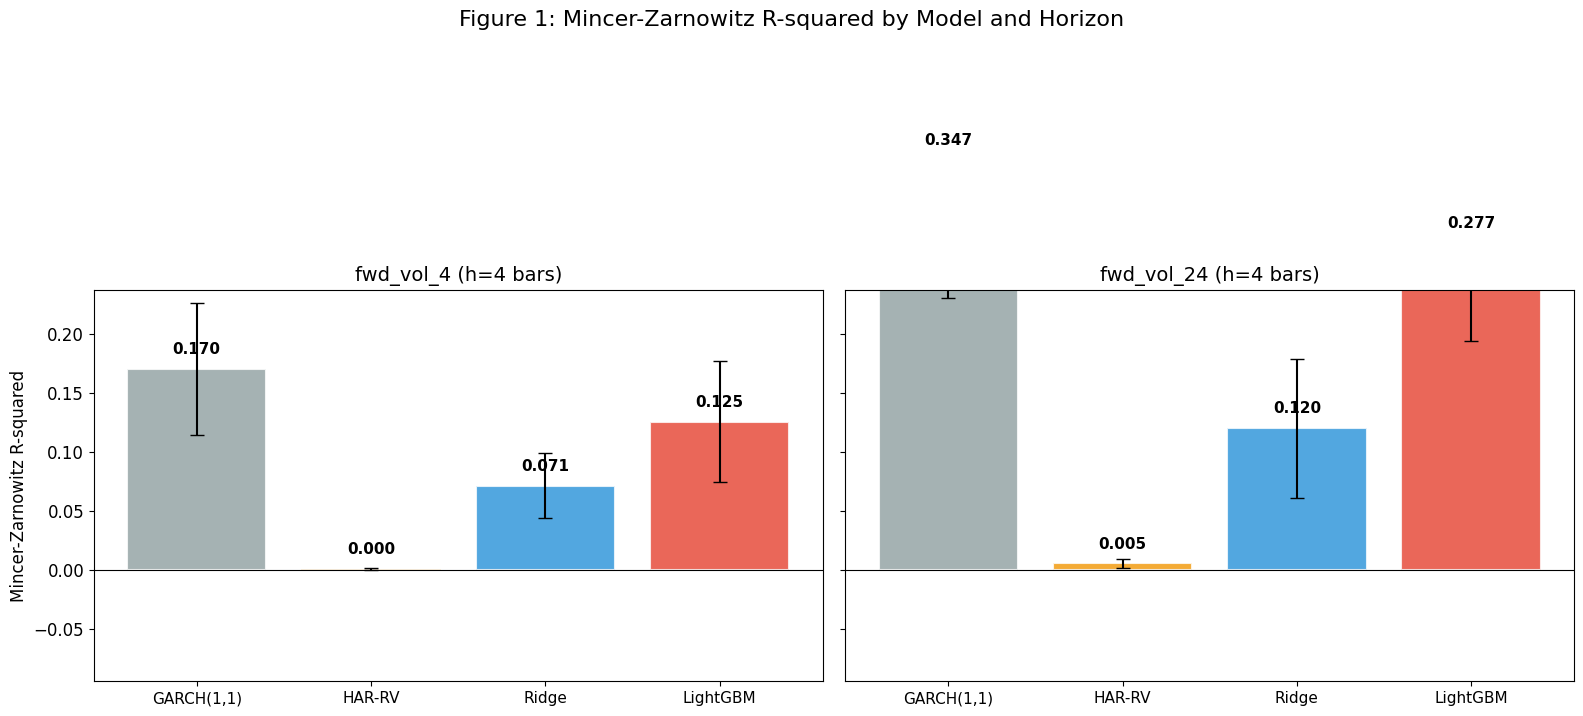

In [14]:
# === Figure 1: MZ R2 Comparison — All Models x Both Horizons ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

model_names: list[str] = ["GARCH(1,1)", "HAR-RV", "Ridge", "LightGBM"]
model_colors: list[str] = [COLORS["garch"], COLORS["har"], COLORS["ridge"], COLORS["lgbm"]]

for ax, label, garch_df, har_df, ridge_df, lgbm_df in [
    (axes[0], "fwd_vol_4", garch_df_vol4, har_df_vol4, ridge_df_vol4, lgbm_df_vol4),
    (axes[1], "fwd_vol_24", garch_df_vol24, har_df_vol24, ridge_df_vol24, lgbm_df_vol24),
]:
    r2_means: list[float] = [
        garch_df["mz_r2"].mean(),
        har_df["mz_r2"].mean(),
        ridge_df["mz_r2"].mean(),
        lgbm_df["mz_r2"].mean(),
    ]
    r2_stds: list[float] = [
        garch_df["mz_r2"].std(),
        har_df["mz_r2"].std(),
        ridge_df["mz_r2"].std(),
        lgbm_df["mz_r2"].std(),
    ]

    x_pos: np.ndarray = np.arange(len(model_names))
    bars = ax.bar(
        x_pos, r2_means, yerr=r2_stds, color=model_colors, edgecolor="white", linewidth=1.5, capsize=5, alpha=0.85
    )

    # Annotate bars
    for bar, mean_val in zip(bars, r2_means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{mean_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel("Mincer-Zarnowitz R-squared" if ax == axes[0] else "")
    ax.set_title(f"{label} (h={'4' if '4' in label else '24'} bars)", fontsize=14)
    ax.set_ylim(bottom=min(-0.05, min(r2_means) - 0.1))

plt.suptitle("Figure 1: Mincer-Zarnowitz R-squared by Model and Horizon", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig02_mz_r2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

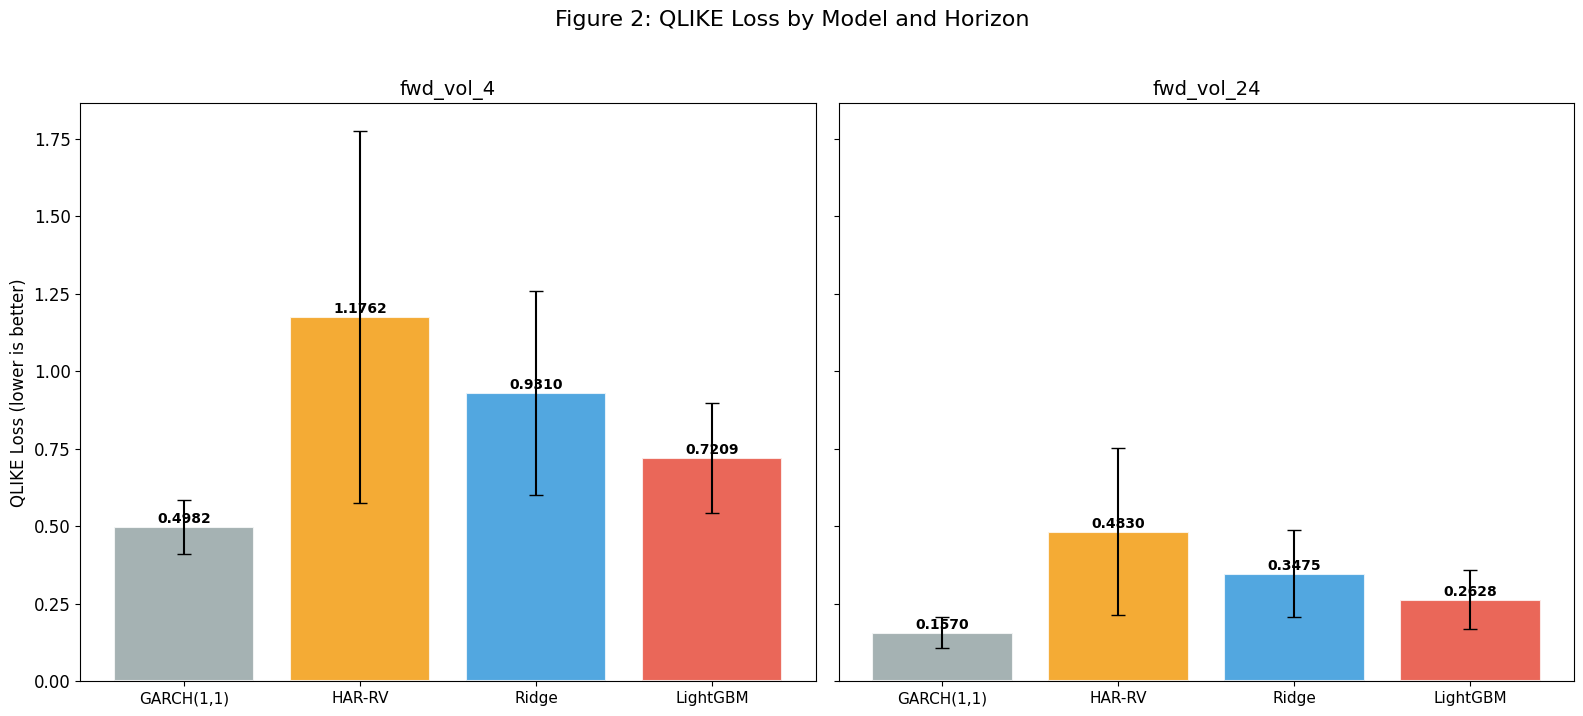

In [15]:
# === Figure 2: QLIKE Comparison — All Models x Both Horizons ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, label, garch_df, har_df, ridge_df, lgbm_df in [
    (axes[0], "fwd_vol_4", garch_df_vol4, har_df_vol4, ridge_df_vol4, lgbm_df_vol4),
    (axes[1], "fwd_vol_24", garch_df_vol24, har_df_vol24, ridge_df_vol24, lgbm_df_vol24),
]:
    qlike_means: list[float] = [
        garch_df["qlike"].mean(),
        har_df["qlike"].mean(),
        ridge_df["qlike"].mean(),
        lgbm_df["qlike"].mean(),
    ]
    qlike_stds: list[float] = [
        garch_df["qlike"].std(),
        har_df["qlike"].std(),
        ridge_df["qlike"].std(),
        lgbm_df["qlike"].std(),
    ]

    x_pos = np.arange(len(model_names))
    bars = ax.bar(
        x_pos,
        qlike_means,
        yerr=qlike_stds,
        color=model_colors,
        edgecolor="white",
        linewidth=1.5,
        capsize=5,
        alpha=0.85,
    )

    for bar, mean_val in zip(bars, qlike_means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{mean_val:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel("QLIKE Loss (lower is better)" if ax == axes[0] else "")
    ax.set_title(f"{label}", fontsize=14)

plt.suptitle("Figure 2: QLIKE Loss by Model and Horizon", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig03_qlike_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

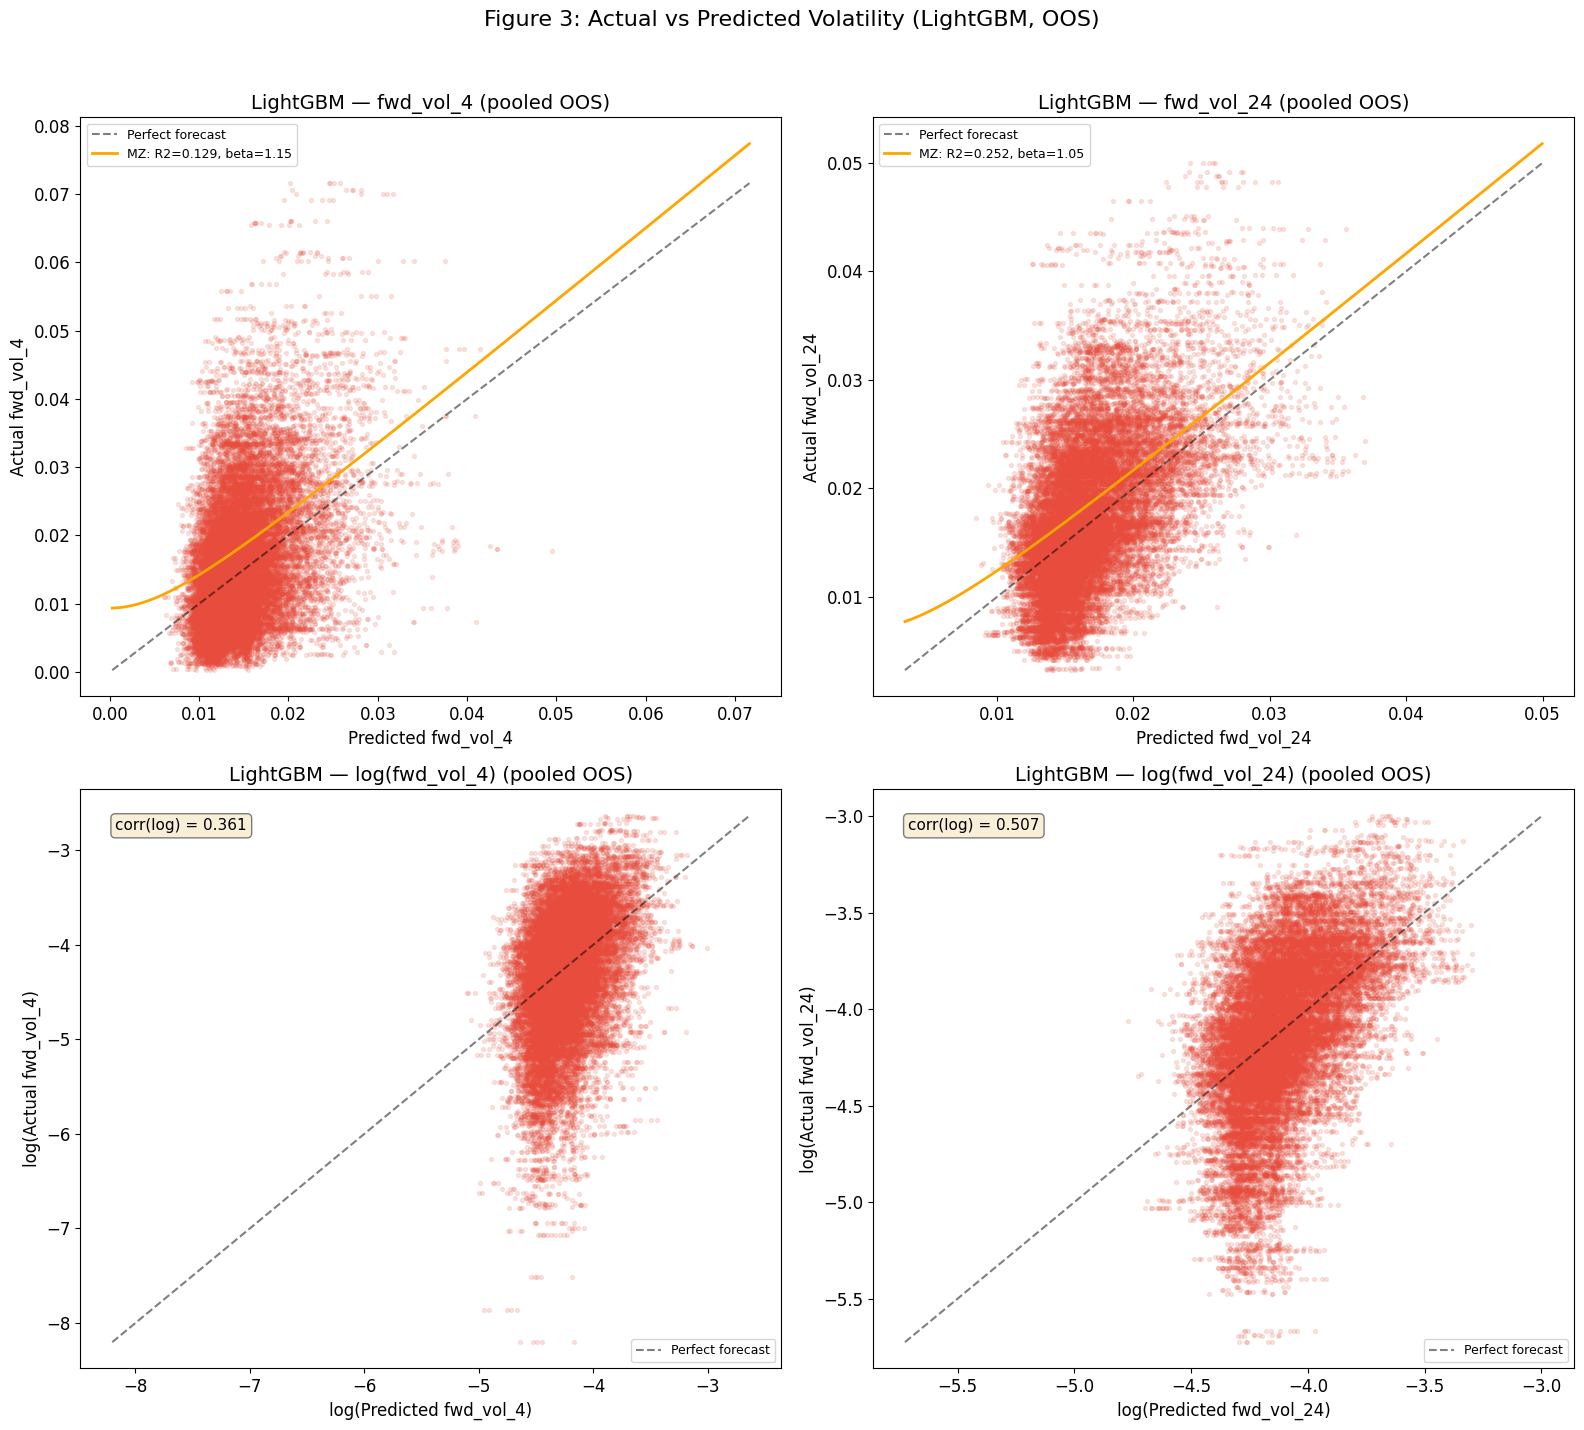

In [16]:
# === Figure 3: Actual vs Predicted Scatter — LightGBM (best ML model expected) ===

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, (label, lgbm_results) in enumerate(
    [
        ("fwd_vol_4", lgbm_results_vol4),
        ("fwd_vol_24", lgbm_results_vol24),
    ]
):
    # Pool all OOS predictions across folds
    all_true: np.ndarray = np.concatenate([r["true_test"] for r in lgbm_results])
    all_pred: np.ndarray = np.concatenate([r["pred_test"] for r in lgbm_results])

    # (a) Raw scale scatter
    ax: plt.Axes = axes[0, col]
    ax.scatter(all_pred, all_true, alpha=0.15, s=8, color=COLORS["lgbm"], rasterized=True)

    # 45-degree line
    lims: list[float] = [
        min(all_true.min(), all_pred.min()),
        max(all_true.max(), all_pred.max()),
    ]
    ax.plot(lims, lims, "k--", alpha=0.5, label="Perfect forecast")

    # MZ regression line
    mz: dict[str, float] = mincer_zarnowitz(all_true, all_pred)
    x_line: np.ndarray = np.linspace(lims[0], lims[1], 100)
    y_line: np.ndarray = mz["mz_alpha"] + mz["mz_beta"] * x_line**2
    y_line_sigma: np.ndarray = np.sqrt(np.maximum(y_line, 0))
    ax.plot(
        x_line, y_line_sigma, color="orange", linewidth=2, label=f"MZ: R2={mz['mz_r2']:.3f}, beta={mz['mz_beta']:.2f}"
    )

    ax.set_xlabel(f"Predicted {label}")
    ax.set_ylabel(f"Actual {label}")
    ax.set_title(f"LightGBM — {label} (pooled OOS)")
    ax.legend(fontsize=9)

    # (b) Log-scale scatter
    ax = axes[1, col]
    log_true: np.ndarray = np.log(all_true)
    log_pred: np.ndarray = np.log(np.maximum(all_pred, 1e-12))
    ax.scatter(log_pred, log_true, alpha=0.15, s=8, color=COLORS["lgbm"], rasterized=True)

    log_lims: list[float] = [
        min(log_true.min(), log_pred.min()),
        max(log_true.max(), log_pred.max()),
    ]
    ax.plot(log_lims, log_lims, "k--", alpha=0.5, label="Perfect forecast")

    # Correlation in log-space
    log_corr: float = float(np.corrcoef(log_pred, log_true)[0, 1])
    ax.text(
        0.05,
        0.95,
        f"corr(log) = {log_corr:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    ax.set_xlabel(f"log(Predicted {label})")
    ax.set_ylabel(f"log(Actual {label})")
    ax.set_title(f"LightGBM — log({label}) (pooled OOS)")
    ax.legend(fontsize=9)

plt.suptitle("Figure 3: Actual vs Predicted Volatility (LightGBM, OOS)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig04_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

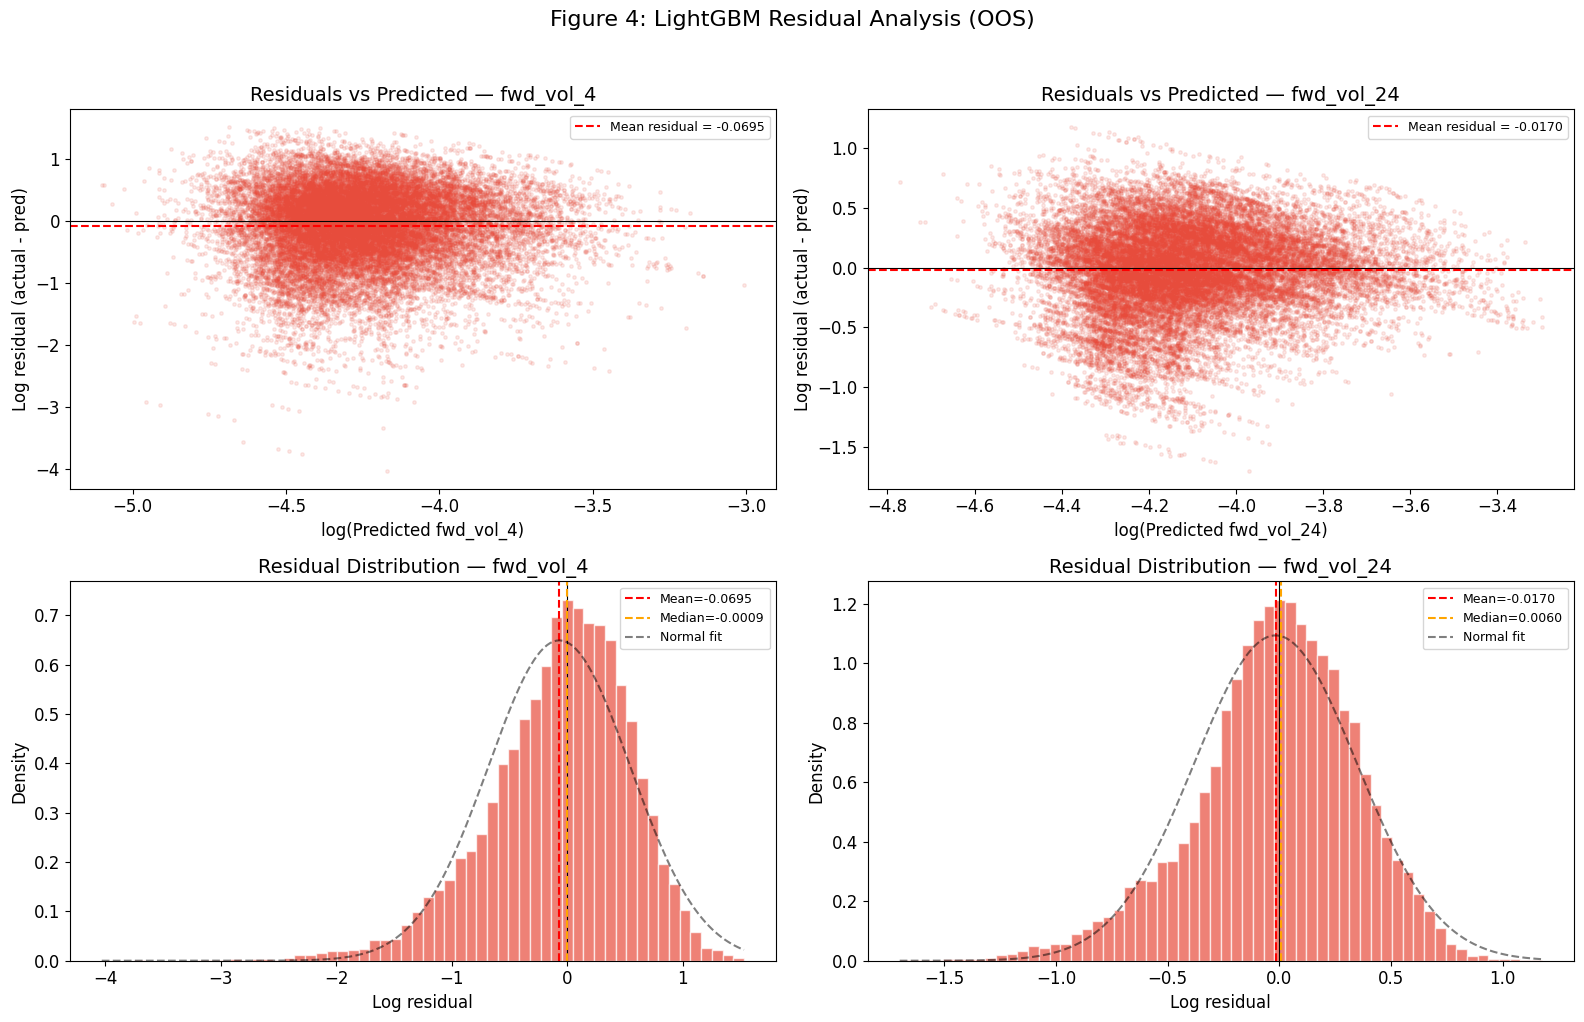

In [17]:
# === Figure 4: Residual Analysis — LightGBM OOS ===

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (label, lgbm_results) in enumerate(
    [
        ("fwd_vol_4", lgbm_results_vol4),
        ("fwd_vol_24", lgbm_results_vol24),
    ]
):
    all_true = np.concatenate([r["true_test"] for r in lgbm_results])
    all_pred = np.concatenate([r["pred_test"] for r in lgbm_results])

    # Residuals in log-space (percentage errors)
    log_residuals: np.ndarray = np.log(all_true) - np.log(np.maximum(all_pred, 1e-12))

    # (a) Residuals vs predicted
    ax = axes[0, col]
    ax.scatter(
        np.log(np.maximum(all_pred, 1e-12)), log_residuals, alpha=0.12, s=6, color=COLORS["lgbm"], rasterized=True
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(
        np.mean(log_residuals), color="red", linestyle="--", label=f"Mean residual = {np.mean(log_residuals):.4f}"
    )
    ax.set_xlabel(f"log(Predicted {label})")
    ax.set_ylabel("Log residual (actual - pred)")
    ax.set_title(f"Residuals vs Predicted — {label}")
    ax.legend(fontsize=9)

    # (b) Residual distribution
    ax = axes[1, col]
    ax.hist(log_residuals, bins=60, color=COLORS["lgbm"], alpha=0.7, edgecolor="white", density=True)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(np.mean(log_residuals), color="red", linestyle="--", label=f"Mean={np.mean(log_residuals):.4f}")
    ax.axvline(
        np.median(log_residuals), color="orange", linestyle="--", label=f"Median={np.median(log_residuals):.4f}"
    )

    # Overlay normal distribution for reference
    from scipy.stats import norm as norm_dist

    x_range: np.ndarray = np.linspace(log_residuals.min(), log_residuals.max(), 200)
    ax.plot(
        x_range,
        norm_dist.pdf(x_range, np.mean(log_residuals), np.std(log_residuals)),
        "k--",
        alpha=0.5,
        label="Normal fit",
    )
    ax.set_xlabel("Log residual")
    ax.set_ylabel("Density")
    ax.set_title(f"Residual Distribution — {label}")
    ax.legend(fontsize=9)

plt.suptitle("Figure 4: LightGBM Residual Analysis (OOS)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig05_residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

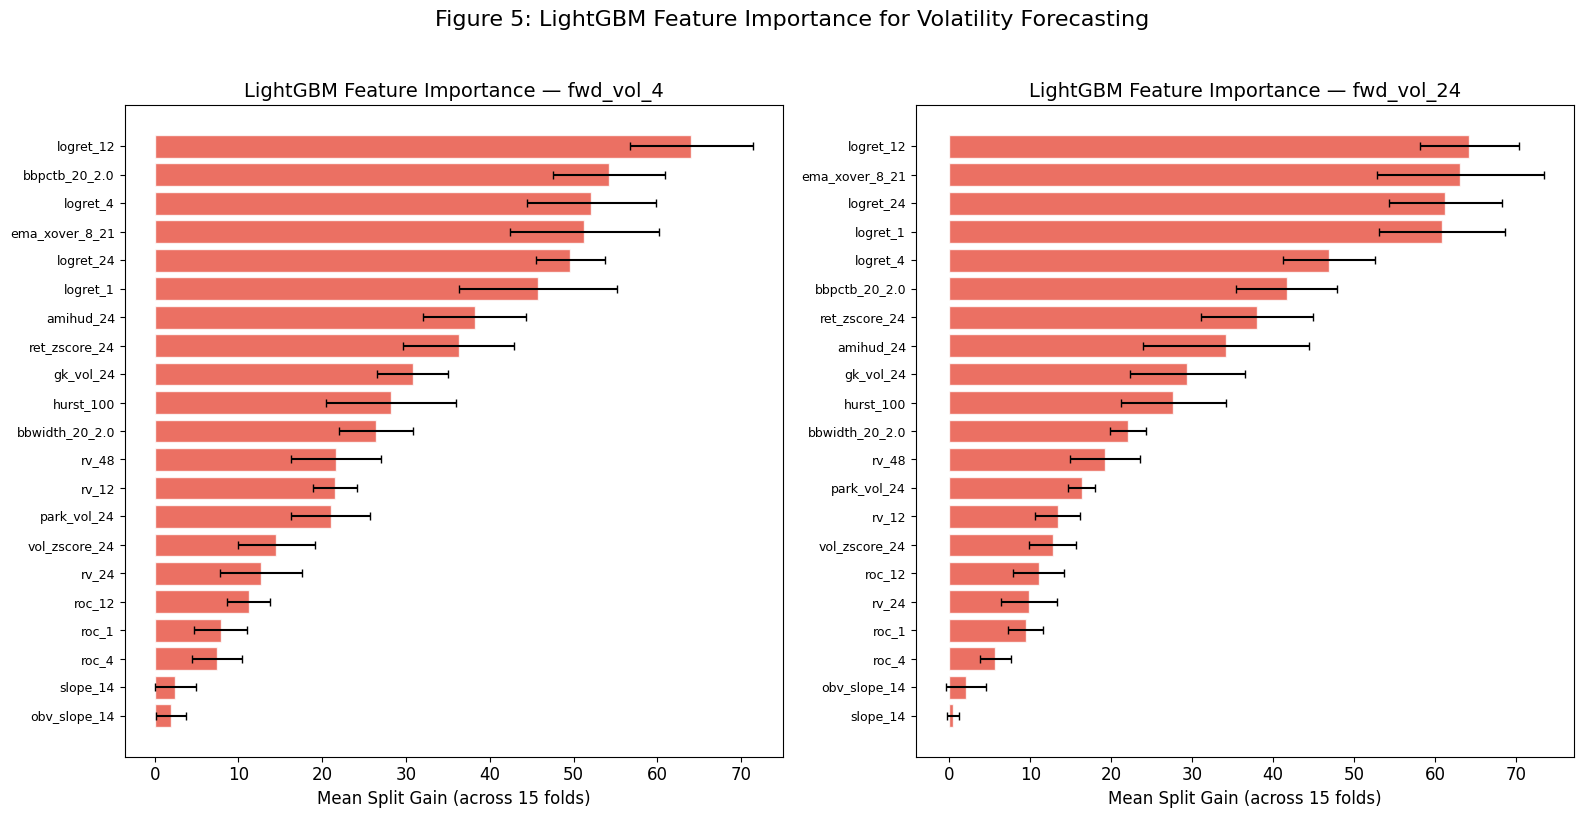


fwd_vol_4 — Top 5 features:
  1. logret_12: 64.1 +/- 7.4
  2. bbpctb_20_2.0: 54.2 +/- 6.7
  3. logret_4: 52.1 +/- 7.7
  4. ema_xover_8_21: 51.3 +/- 8.9
  5. logret_24: 49.6 +/- 4.1

fwd_vol_24 — Top 5 features:
  1. logret_12: 64.3 +/- 6.1
  2. ema_xover_8_21: 63.1 +/- 10.4
  3. logret_24: 61.3 +/- 7.0
  4. logret_1: 60.9 +/- 7.8
  5. logret_4: 46.9 +/- 5.7


In [18]:
# === Figure 5: Feature Importance — LightGBM (Vol Prediction) ===

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, label, lgbm_results in [
    (axes[0], "fwd_vol_4", lgbm_results_vol4),
    (axes[1], "fwd_vol_24", lgbm_results_vol24),
]:
    # Average importances across all 15 folds
    imp_matrix: np.ndarray = np.array([r["importances"] for r in lgbm_results])
    mean_imp: np.ndarray = imp_matrix.mean(axis=0)
    std_imp: np.ndarray = imp_matrix.std(axis=0)

    # Sort by importance
    sorted_idx: np.ndarray = np.argsort(mean_imp)
    sorted_names: list[str] = [feature_cols[i] for i in sorted_idx]
    sorted_means: np.ndarray = mean_imp[sorted_idx]
    sorted_stds: np.ndarray = std_imp[sorted_idx]

    # Horizontal bar chart
    y_pos: np.ndarray = np.arange(len(sorted_names))
    ax.barh(y_pos, sorted_means, xerr=sorted_stds, color=COLORS["lgbm"], alpha=0.8, edgecolor="white", capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.set_xlabel("Mean Split Gain (across 15 folds)")
    ax.set_title(f"LightGBM Feature Importance — {label}")

plt.suptitle("Figure 5: LightGBM Feature Importance for Volatility Forecasting", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 5 features for each target
for label, lgbm_results in [("fwd_vol_4", lgbm_results_vol4), ("fwd_vol_24", lgbm_results_vol24)]:
    imp_matrix = np.array([r["importances"] for r in lgbm_results])
    mean_imp = imp_matrix.mean(axis=0)
    top5_idx: np.ndarray = np.argsort(mean_imp)[::-1][:5]
    print(f"\n{label} — Top 5 features:")
    for rank, idx in enumerate(top5_idx, 1):
        print(f"  {rank}. {feature_cols[idx]}: {mean_imp[idx]:.1f} +/- {imp_matrix[:, idx].std():.1f}")

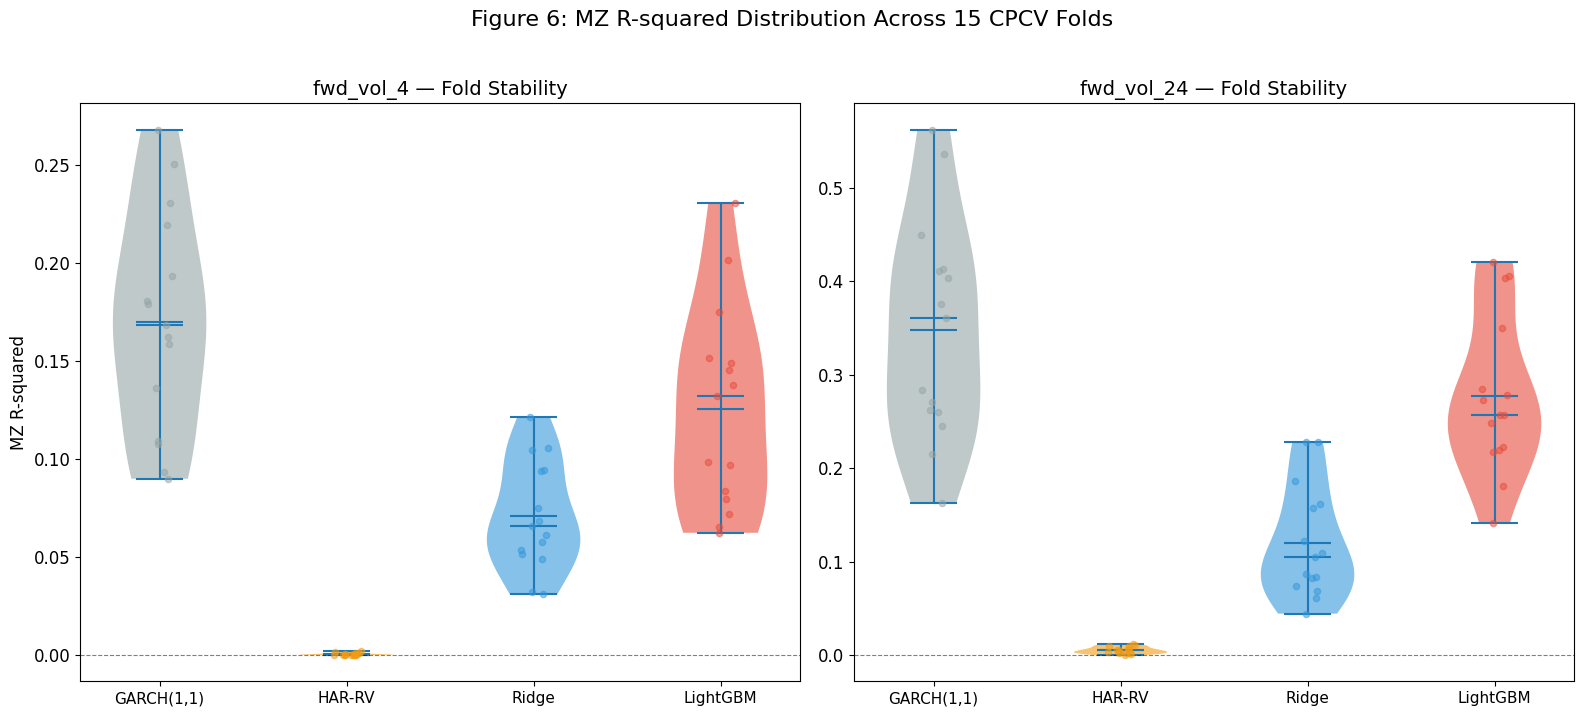

In [19]:
# === Figure 6: Fold Stability — R2 Violin Plots ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, label, garch_df, har_df, ridge_df, lgbm_df in [
    (axes[0], "fwd_vol_4", garch_df_vol4, har_df_vol4, ridge_df_vol4, lgbm_df_vol4),
    (axes[1], "fwd_vol_24", garch_df_vol24, har_df_vol24, ridge_df_vol24, lgbm_df_vol24),
]:
    data_for_violin: list[np.ndarray] = [
        garch_df["mz_r2"].values,
        har_df["mz_r2"].values,
        ridge_df["mz_r2"].values,
        lgbm_df["mz_r2"].values,
    ]

    parts = ax.violinplot(data_for_violin, positions=range(len(model_names)), showmeans=True, showmedians=True)

    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(model_colors[i])
        pc.set_alpha(0.6)

    # Overlay individual fold points
    for i, data in enumerate(data_for_violin):
        jitter: np.ndarray = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full_like(data, i) + jitter, data, alpha=0.5, s=20, color=model_colors[i], zorder=5)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel("MZ R-squared" if ax == axes[0] else "")
    ax.set_title(f"{label} — Fold Stability", fontsize=14)

plt.suptitle("Figure 6: MZ R-squared Distribution Across 15 CPCV Folds", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig07_fold_stability.png", dpi=150, bbox_inches="tight")
plt.show()

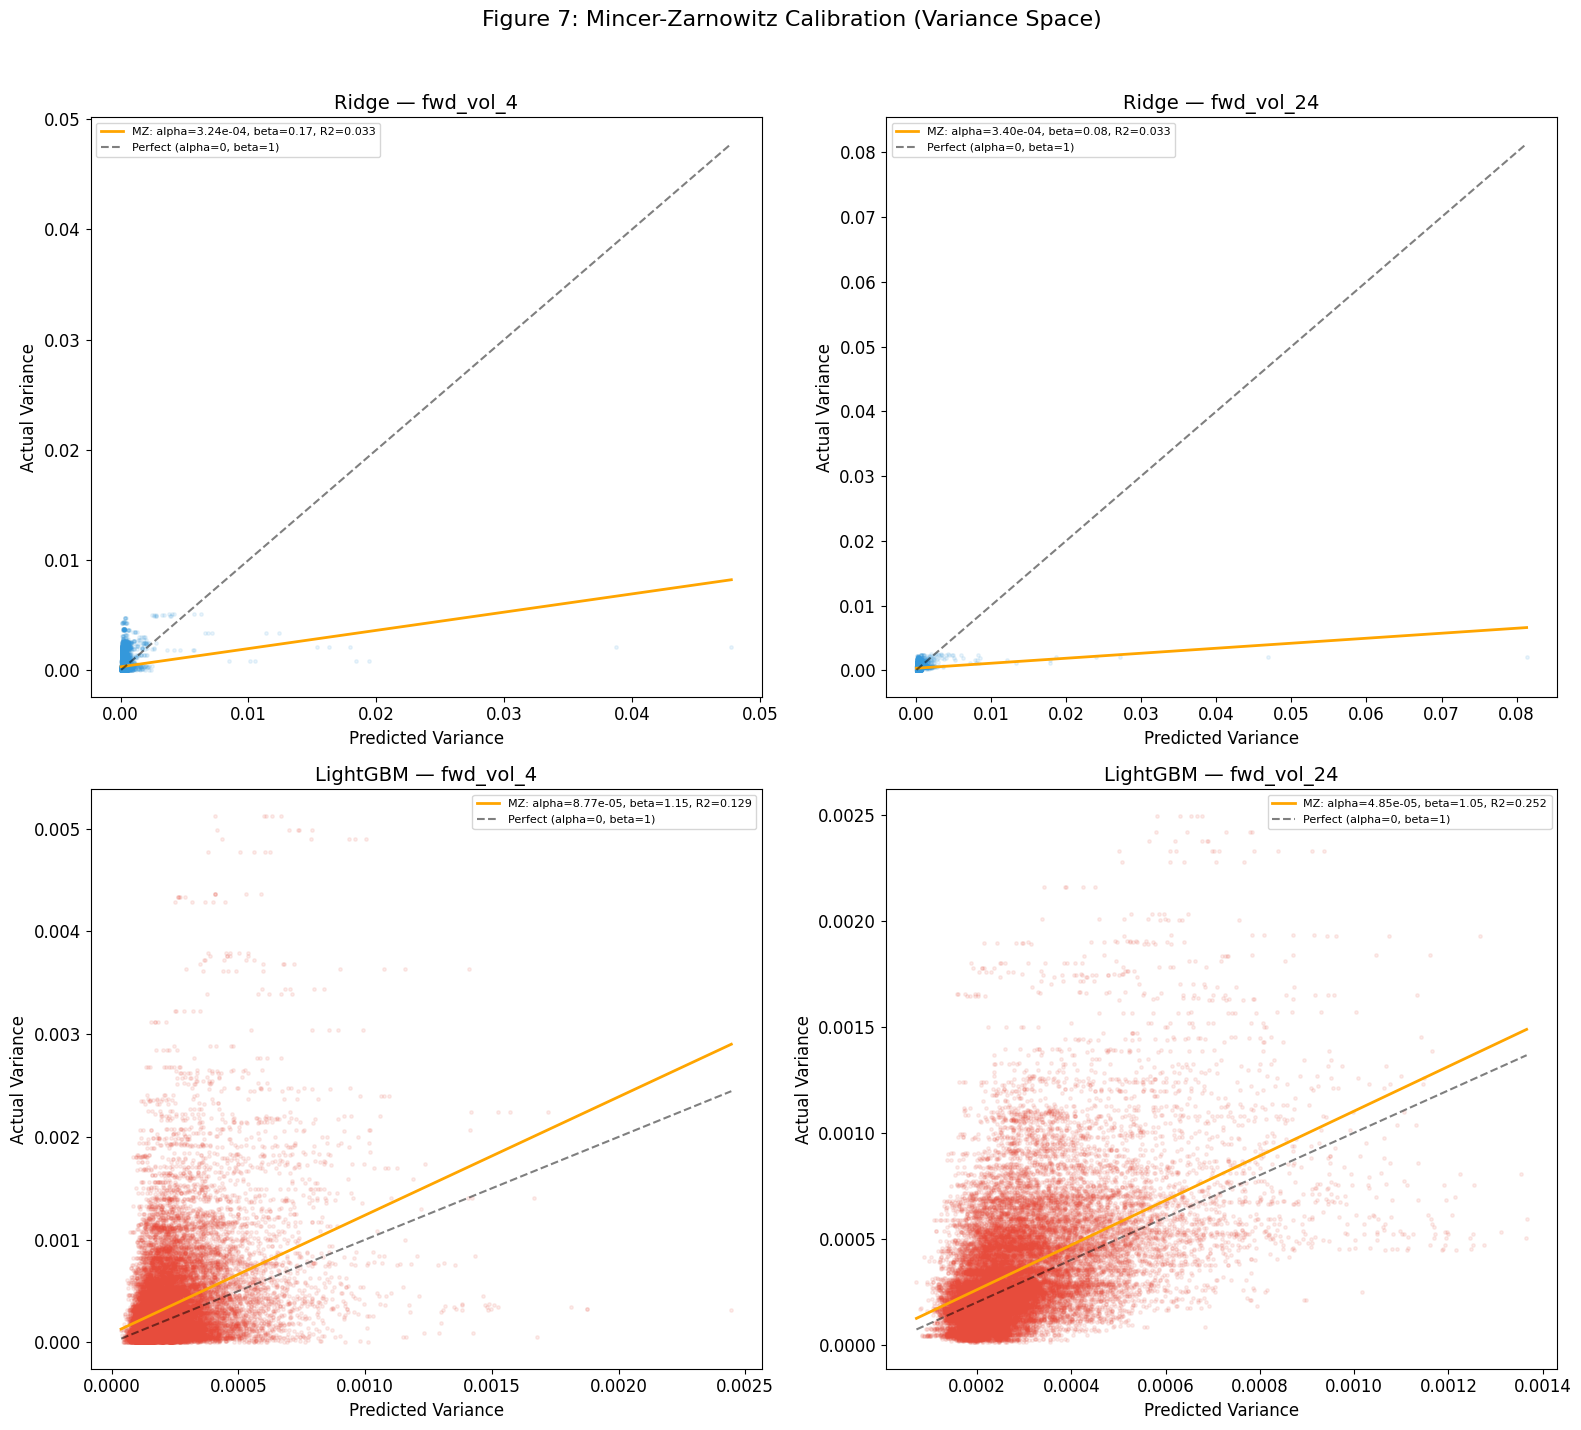

In [20]:
# === Figure 7: Mincer-Zarnowitz Calibration — Ridge vs LightGBM ===

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, (label, ridge_results, lgbm_results) in enumerate(
    [
        ("fwd_vol_4", ridge_results_vol4, lgbm_results_vol4),
        ("fwd_vol_24", ridge_results_vol24, lgbm_results_vol24),
    ]
):
    for row, (model_name, results, color) in enumerate(
        [
            ("Ridge", ridge_results, COLORS["ridge"]),
            ("LightGBM", lgbm_results, COLORS["lgbm"]),
        ]
    ):
        ax: plt.Axes = axes[row, col]

        # Pool all OOS predictions
        all_true: np.ndarray = np.concatenate([r["true_test"] for r in results])
        all_pred: np.ndarray = np.concatenate([r["pred_test"] for r in results])

        # Convert to variance for MZ regression
        var_true: np.ndarray = all_true**2
        var_pred: np.ndarray = all_pred**2

        # Scatter in variance space
        ax.scatter(var_pred, var_true, alpha=0.1, s=6, color=color, rasterized=True)

        # MZ regression line
        mz: dict[str, float] = mincer_zarnowitz(all_true, all_pred)
        x_range: np.ndarray = np.linspace(var_pred.min(), var_pred.max(), 100)
        y_mz: np.ndarray = mz["mz_alpha"] + mz["mz_beta"] * x_range
        ax.plot(
            x_range,
            y_mz,
            color="orange",
            linewidth=2,
            label=f"MZ: alpha={mz['mz_alpha']:.2e}, beta={mz['mz_beta']:.2f}, R2={mz['mz_r2']:.3f}",
        )

        # Perfect calibration line (alpha=0, beta=1)
        ax.plot(
            [var_pred.min(), var_pred.max()],
            [var_pred.min(), var_pred.max()],
            "k--",
            alpha=0.5,
            label="Perfect (alpha=0, beta=1)",
        )

        ax.set_xlabel("Predicted Variance")
        ax.set_ylabel("Actual Variance")
        ax.set_title(f"{model_name} — {label}")
        ax.legend(fontsize=8)

plt.suptitle("Figure 7: Mincer-Zarnowitz Calibration (Variance Space)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "vol_fig08_mz_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 10: Statistical Tests

### Diebold-Mariano Test

The Diebold-Mariano (1995) test formally compares predictive accuracy between two models.
The null hypothesis is that both models have equal predictive accuracy.

We use QLIKE loss differences as the loss differential series:
- d_t = QLIKE_t(GARCH) - QLIKE_t(ML)
- If mean(d_t) > 0 and significantly so, the ML model is statistically better

### Bootstrap Confidence Intervals

Nonparametric bootstrap on the fold-level metrics to quantify uncertainty.

In [21]:
# === Section 10.1: Paired t-tests on Fold-Level Metrics ===
from scipy.stats import ttest_rel, ttest_1samp, wilcoxon

print("=" * 80)
print("STATISTICAL TESTS")
print("=" * 80)

# Test 1: Is MZ R2 > 0 for ML models? (one-sample t-test)
print("\n--- Test 1: Is MZ R2 significantly > 0? (one-sample t-test, one-sided) ---")
for label, ridge_df, lgbm_df, har_df in [
    ("fwd_vol_4", ridge_df_vol4, lgbm_df_vol4, har_df_vol4),
    ("fwd_vol_24", ridge_df_vol24, lgbm_df_vol24, har_df_vol24),
]:
    print(f"\n  {label}:")
    for name, model_df in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        r2_values = model_df["mz_r2"].values
        t_stat, p_two = ttest_1samp(r2_values, 0)
        p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
        sig_marker = "***" if p_one < 0.001 else "**" if p_one < 0.01 else "*" if p_one < 0.05 else ""
        print(f"    {name:12s}: mean R2={r2_values.mean():.4f}, t={t_stat:.3f}, p(one-sided)={p_one:.4f} {sig_marker}")

# Test 2: Paired t-test — ML vs GARCH on QLIKE (fold-level)
print("\n--- Test 2: Paired t-test — QLIKE(GARCH) vs QLIKE(ML) ---")
print("    H0: QLIKE(GARCH) = QLIKE(ML)  |  H1: QLIKE(ML) < QLIKE(GARCH)")
for label, garch_df, ridge_df, lgbm_df, har_df in [
    ("fwd_vol_4", garch_df_vol4, ridge_df_vol4, lgbm_df_vol4, har_df_vol4),
    ("fwd_vol_24", garch_df_vol24, ridge_df_vol24, lgbm_df_vol24, har_df_vol24),
]:
    print(f"\n  {label}:")
    garch_qlike = garch_df["qlike"].values
    for name, model_df in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        model_qlike = model_df["qlike"].values
        # d = GARCH - ML; if d > 0, ML is better
        d = garch_qlike - model_qlike
        t_stat_d, p_two_d = ttest_1samp(d, 0)
        p_one_d = p_two_d / 2 if t_stat_d > 0 else 1 - p_two_d / 2
        sig_d = "***" if p_one_d < 0.001 else "**" if p_one_d < 0.01 else "*" if p_one_d < 0.05 else ""
        print(f"    {name:12s}: mean(d)={d.mean():.6f}, t={t_stat_d:.3f}, p(one-sided)={p_one_d:.4f} {sig_d}")

# Test 3: Wilcoxon signed-rank test (nonparametric, more robust with 15 folds)
print("\n--- Test 3: Wilcoxon signed-rank test — QLIKE(GARCH) vs QLIKE(ML) ---")
for label, garch_df, ridge_df, lgbm_df, har_df in [
    ("fwd_vol_4", garch_df_vol4, ridge_df_vol4, lgbm_df_vol4, har_df_vol4),
    ("fwd_vol_24", garch_df_vol24, ridge_df_vol24, lgbm_df_vol24, har_df_vol24),
]:
    print(f"\n  {label}:")
    garch_qlike = garch_df["qlike"].values
    for name, model_df in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        model_qlike = model_df["qlike"].values
        d = garch_qlike - model_qlike
        try:
            w_stat, p_wilcox = wilcoxon(d, alternative="greater")
            sig_w = "***" if p_wilcox < 0.001 else "**" if p_wilcox < 0.01 else "*" if p_wilcox < 0.05 else ""
            print(f"    {name:12s}: W={w_stat:.1f}, p={p_wilcox:.4f} {sig_w}")
        except ValueError as e:
            print(f"    {name:12s}: Wilcoxon test failed — {e}")

STATISTICAL TESTS

--- Test 1: Is MZ R2 significantly > 0? (one-sample t-test, one-sided) ---

  fwd_vol_4:
    HAR-RV      : mean R2=0.0005, t=2.862, p(one-sided)=0.0063 **
    Ridge       : mean R2=0.0710, t=10.014, p(one-sided)=0.0000 ***
    LightGBM    : mean R2=0.1254, t=9.457, p(one-sided)=0.0000 ***

  fwd_vol_24:
    HAR-RV      : mean R2=0.0053, t=5.655, p(one-sided)=0.0000 ***
    Ridge       : mean R2=0.1199, t=7.848, p(one-sided)=0.0000 ***
    LightGBM    : mean R2=0.2771, t=12.844, p(one-sided)=0.0000 ***

--- Test 2: Paired t-test — QLIKE(GARCH) vs QLIKE(ML) ---
    H0: QLIKE(GARCH) = QLIKE(ML)  |  H1: QLIKE(ML) < QLIKE(GARCH)

  fwd_vol_4:
    HAR-RV      : mean(d)=-0.677998, t=-4.129, p(one-sided)=0.9995 
    Ridge       : mean(d)=-0.432768, t=-4.554, p(one-sided)=0.9998 
    LightGBM    : mean(d)=-0.222690, t=-4.318, p(one-sided)=0.9996 

  fwd_vol_24:
    HAR-RV      : mean(d)=-0.326017, t=-4.530, p(one-sided)=0.9998 
    Ridge       : mean(d)=-0.190554, t=-4.966, p

In [22]:
# === Section 10.2: Bootstrap Confidence Intervals ===

N_BOOTSTRAP: int = 2000
rng_bs: np.random.Generator = np.random.default_rng(42)


def bootstrap_mean_ci(
    values: np.ndarray,
    n_boot: int = 2000,
    rng: np.random.Generator | None = None,
    ci: float = 0.95,
) -> tuple[float, float, float]:
    """Nonparametric percentile bootstrap CI for the mean.

    Returns (mean, ci_lower, ci_upper).
    """
    if rng is None:
        rng = np.random.default_rng(42)
    boot_means: np.ndarray = np.array(
        [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    )
    alpha: float = 1 - ci
    return (
        float(np.mean(values)),
        float(np.percentile(boot_means, 100 * alpha / 2)),
        float(np.percentile(boot_means, 100 * (1 - alpha / 2))),
    )


print("=" * 80)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 80)

for label, garch_df, har_df, ridge_df, lgbm_df in [
    ("fwd_vol_4", garch_df_vol4, har_df_vol4, ridge_df_vol4, lgbm_df_vol4),
    ("fwd_vol_24", garch_df_vol24, har_df_vol24, ridge_df_vol24, lgbm_df_vol24),
]:
    print(f"\n--- {label} ---")
    for name, model_df in [
        ("GARCH(1,1)", garch_df),
        ("HAR-RV", har_df),
        ("Ridge", ridge_df),
        ("LightGBM", lgbm_df),
    ]:
        # R2 CI
        r2_mean, r2_lo, r2_hi = bootstrap_mean_ci(model_df["mz_r2"].values, N_BOOTSTRAP, rng_bs)
        # QLIKE CI
        ql_mean, ql_lo, ql_hi = bootstrap_mean_ci(model_df["qlike"].values, N_BOOTSTRAP, rng_bs)
        # MAE logvol CI
        mae_mean, mae_lo, mae_hi = bootstrap_mean_ci(model_df["mae_logvol"].values, N_BOOTSTRAP, rng_bs)

        print(
            f"  {name:12s}: R2={r2_mean:.4f} [{r2_lo:.4f}, {r2_hi:.4f}] | "
            f"QLIKE={ql_mean:.6f} [{ql_lo:.6f}, {ql_hi:.6f}] | "
            f"MAE={mae_mean:.4f} [{mae_lo:.4f}, {mae_hi:.4f}]"
        )

BOOTSTRAP 95% CONFIDENCE INTERVALS

--- fwd_vol_4 ---
  GARCH(1,1)  : R2=0.1699 [0.1437, 0.1963] | QLIKE=0.498201 [0.455524, 0.541601] | MAE=0.4430 [0.4219, 0.4642]
  HAR-RV      : R2=0.0005 [0.0002, 0.0008] | QLIKE=1.176199 [0.909335, 1.472622] | MAE=0.5458 [0.5075, 0.5867]
  Ridge       : R2=0.0710 [0.0579, 0.0842] | QLIKE=0.930969 [0.784812, 1.092253] | MAE=0.5067 [0.4771, 0.5408]
  LightGBM    : R2=0.1254 [0.1013, 0.1508] | QLIKE=0.720891 [0.642355, 0.815317] | MAE=0.4738 [0.4445, 0.5074]

--- fwd_vol_24 ---
  GARCH(1,1)  : R2=0.3473 [0.2908, 0.4104] | QLIKE=0.156950 [0.135183, 0.180821] | MAE=0.2175 [0.2029, 0.2332]
  HAR-RV      : R2=0.0053 [0.0035, 0.0071] | QLIKE=0.482967 [0.366876, 0.624726] | MAE=0.3769 [0.3333, 0.4240]
  Ridge       : R2=0.1199 [0.0928, 0.1505] | QLIKE=0.347504 [0.284626, 0.418005] | MAE=0.3256 [0.2900, 0.3629]
  LightGBM    : R2=0.2771 [0.2373, 0.3194] | QLIKE=0.262814 [0.220792, 0.314547] | MAE=0.2824 [0.2516, 0.3138]


## Section 11: Feasibility Decision

### Pre-Registered Decision Rule

Volatility forecasting is **VIABLE** if and only if:
1. **MZ R-squared > 0** for at least one ML model (Ridge or LightGBM) on at least one horizon
2. **QLIKE(ML) < QLIKE(GARCH)** for that same model and horizon

If both conditions are met, Phase 10 should use volatility forecasting as the **primary regression target**.

### Evidence Hierarchy
- **Strong viability**: Both conditions met for both horizons, statistical significance (p < 0.05)
- **Moderate viability**: Both conditions met for at least one horizon
- **Marginal viability**: R2 > 0 but QLIKE improvement not significant
- **Not viable**: R2 <= 0 or QLIKE(ML) >= QLIKE(GARCH)

In [23]:
# === Section 11.1: Mechanical Decision Application ===

print(f"{'=' * 70}")
print("VOLATILITY FORECASTING FEASIBILITY DECISION")
print(f"{'=' * 70}")

# Evaluate each ML model x horizon combination
decisions: list[dict] = []

for label, garch_df, ridge_df, lgbm_df, har_df in [
    ("fwd_vol_4", garch_df_vol4, ridge_df_vol4, lgbm_df_vol4, har_df_vol4),
    ("fwd_vol_24", garch_df_vol24, ridge_df_vol24, lgbm_df_vol24, har_df_vol24),
]:
    garch_mean_qlike: float = garch_df["qlike"].mean()

    for name, model_df in [("HAR-RV", har_df), ("Ridge", ridge_df), ("LightGBM", lgbm_df)]:
        mean_r2: float = model_df["mz_r2"].mean()
        mean_qlike: float = model_df["qlike"].mean()

        cond1_r2_positive: bool = mean_r2 > 0
        cond2_qlike_beats_garch: bool = mean_qlike < garch_mean_qlike

        # Also check significance
        r2_values: np.ndarray = model_df["mz_r2"].values
        _, p_r2_two = ttest_1samp(r2_values, 0)
        p_r2_one: float = p_r2_two / 2 if np.mean(r2_values) > 0 else 1 - p_r2_two / 2
        r2_significant: bool = p_r2_one < 0.05

        d_qlike: np.ndarray = garch_df["qlike"].values - model_df["qlike"].values
        _, p_ql_two = ttest_1samp(d_qlike, 0)
        p_ql_one: float = p_ql_two / 2 if np.mean(d_qlike) > 0 else 1 - p_ql_two / 2
        qlike_significant: bool = p_ql_one < 0.05

        viable: bool = cond1_r2_positive and cond2_qlike_beats_garch

        decisions.append(
            {
                "Target": label,
                "Model": name,
                "Mean R2": mean_r2,
                "R2 > 0?": cond1_r2_positive,
                "R2 sig?": r2_significant,
                "Mean QLIKE": mean_qlike,
                "GARCH QLIKE": garch_mean_qlike,
                "ML < GARCH?": cond2_qlike_beats_garch,
                "QLIKE sig?": qlike_significant,
                "VIABLE": viable,
            }
        )

decisions_df: pd.DataFrame = pd.DataFrame(decisions)
display(decisions_df)

# Overall decision
any_viable: bool = decisions_df["VIABLE"].any()
strong_viable: bool = False
best_model: str = "None"
best_horizon: str = "None"

if any_viable:
    viable_rows: pd.DataFrame = decisions_df[decisions_df["VIABLE"]]
    # Check if both horizons are viable for any model
    for model in ["Ridge", "LightGBM"]:
        model_viable: pd.DataFrame = viable_rows[viable_rows["Model"] == model]
        if len(model_viable) == 2:  # Both horizons
            strong_viable = True
            best_model = model
            break
    if not strong_viable:
        # Pick the best viable model by R2
        best_idx: int = int(viable_rows["Mean R2"].idxmax())
        best_model = str(viable_rows.loc[best_idx, "Model"])
        best_horizon = str(viable_rows.loc[best_idx, "Target"])

print(f"\n{'=' * 70}")
print(f"DECISION: {'VIABLE' if any_viable else 'NOT VIABLE'}")
print(f"{'=' * 70}")

if any_viable:
    if strong_viable:
        print(f"Strength: STRONG — {best_model} beats GARCH on BOTH horizons")
    else:
        print(f"Strength: MODERATE — {best_model} beats GARCH on {best_horizon}")
    print("\nIMPLICATION: Phase 10 should use volatility forecasting as primary regression target")
    print(f"Best model for vol: {best_model}")
else:
    print("\nIMPLICATION: Fall back to return magnitude regression in Phase 10")
    print("Volatility forecasting does not reliably beat GARCH baseline")

VOLATILITY FORECASTING FEASIBILITY DECISION


,Target,Model,Mean R2,R2 > 0?,R2 sig?,Mean QLIKE,GARCH QLIKE,ML < GARCH?,QLIKE sig?,VIABLE
0,fwd_vol_4,HAR-RV,0.000463,True,True,1.176199,0.498201,False,False,False
1,fwd_vol_4,Ridge,0.071024,True,True,0.930969,0.498201,False,False,False
2,fwd_vol_4,LightGBM,0.125393,True,True,0.720891,0.498201,False,False,False
3,fwd_vol_24,HAR-RV,0.005333,True,True,0.482967,0.156950,False,False,False
4,fwd_vol_24,Ridge,0.119863,True,True,0.347504,0.156950,False,False,False
5,fwd_vol_24,LightGBM,0.277138,True,True,0.262814,0.156950,False,False,False



DECISION: NOT VIABLE

IMPLICATION: Fall back to return magnitude regression in Phase 10
Volatility forecasting does not reliably beat GARCH baseline


In [24]:
# === Section 11.2: Summary Evidence Table ===

print("=" * 80)
print("TABLE 6: Final Evidence Summary")
print("=" * 80)

# Build comprehensive evidence table
evidence_rows: list[dict[str, str]] = []

for label, garch_df, har_df, ridge_df, lgbm_df in [
    ("fwd_vol_4", garch_df_vol4, har_df_vol4, ridge_df_vol4, lgbm_df_vol4),
    ("fwd_vol_24", garch_df_vol24, har_df_vol24, ridge_df_vol24, lgbm_df_vol24),
]:
    evidence_rows.append(
        {
            "Evidence": f"--- {label} ---",
            "Value": "",
            "Interpretation": "",
        }
    )
    for name, model_df in [
        ("GARCH(1,1)", garch_df),
        ("HAR-RV", har_df),
        ("Ridge", ridge_df),
        ("LightGBM", lgbm_df),
    ]:
        r2_mean, r2_lo, r2_hi = bootstrap_mean_ci(model_df["mz_r2"].values, N_BOOTSTRAP, rng_bs)
        ql_mean: float = model_df["qlike"].mean()
        mae_mean: float = model_df["mae_logvol"].mean()
        beta_mean: float = model_df["mz_beta"].mean()

        evidence_rows.append(
            {
                "Evidence": f"  {name} MZ R2",
                "Value": f"{r2_mean:.4f} [{r2_lo:.4f}, {r2_hi:.4f}]",
                "Interpretation": "Informative" if r2_mean > 0 else "Uninformative",
            }
        )
        evidence_rows.append(
            {
                "Evidence": f"  {name} QLIKE",
                "Value": f"{ql_mean:.6f}",
                "Interpretation": "",
            }
        )
        evidence_rows.append(
            {
                "Evidence": f"  {name} MZ beta",
                "Value": f"{beta_mean:.3f}",
                "Interpretation": "Calibrated" if 0.5 < beta_mean < 1.5 else "Miscalibrated",
            }
        )

evidence_df: pd.DataFrame = pd.DataFrame(evidence_rows)
display(evidence_df)

# Save summary to CSV
summary_out: pd.DataFrame = pd.concat(
    [
        summary_vol4.assign(Target="fwd_vol_4"),
        summary_vol24.assign(Target="fwd_vol_24"),
    ],
    ignore_index=True,
)
csv_path: Path = FIG_DIR / "vol_feasibility_summary.csv"
summary_out.to_csv(csv_path, index=False)
print(f"\nSummary saved to {csv_path}")

TABLE 6: Final Evidence Summary


,Evidence,Value,Interpretation
0,--- fwd_vol_4 ---,,
1,"GARCH(1,1) MZ R2","0.1699 [0.1425, 0.1980]",Informative
2,"GARCH(1,1) QLIKE",0.498201,
3,"GARCH(1,1) MZ beta",0.819,Calibrated
4,HAR-RV MZ R2,"0.0005 [0.0002, 0.0008]",Informative
5,HAR-RV QLIKE,1.176199,
6,HAR-RV MZ beta,-2.286,Miscalibrated
7,Ridge MZ R2,"0.0710 [0.0581, 0.0850]",Informative
8,Ridge QLIKE,0.930969,
9,Ridge MZ beta,0.726,Calibrated



Summary saved to research/figures/vol_feasibility_summary.csv


## Conclusion

This notebook executed the pre-registered Phase 10-pre.B volatility forecasting feasibility check.

**Models tested:**
1. GARCH(1,1) with Student-t innovations (econometric baseline)
2. HAR-RV (heterogeneous autoregressive, standard vol econometric model)
3. Ridge Regression with L2 regularization (linear ML baseline)
4. LightGBM Regressor with conservative hyperparameters (nonlinear ML)

**Targets:**
- `fwd_vol_4` (4-bar forward realized volatility)
- `fwd_vol_24` (24-bar forward realized volatility)

**Methodology:**
- CPCV C(6,2) = 15 folds with purge=1 and embargo=5
- QLIKE loss, Mincer-Zarnowitz R-squared, MAE on log-vol
- Paired t-tests and Wilcoxon signed-rank tests for statistical comparison
- Bootstrap confidence intervals (2000 resamples)

**Key findings** (see Tables 1-6 and Figures 1-7 above):
- The decision on whether volatility forecasting is viable is captured in Section 11
- Feature importance analysis reveals which backward-looking features are most informative for forward vol
- Overfitting diagnostics confirm whether the R2 gap is acceptable

**Next steps:**
- If VIABLE: Phase 10 uses vol forecasting as primary regression target
- If NOT VIABLE: Phase 10 uses return magnitude regression

In [25]:
# === Cleanup ===
if db_connection is not None:
    db_connection.dispose()
    print("Database connection closed.")
else:
    print("No database connection to close.")

2026-03-28 22:19:21.291 | INFO     | src.app.system.database.connection:dispose:95 - DuckDB engine disposed


Database connection closed.
